In [1]:
import numpy as np

# ============================================================
# Utilities
# ============================================================

def make_random_spd(k: int, rng: np.random.Generator, jitter: float = 1e-6) -> np.ndarray:
    A = rng.normal(size=(k, k))
    B = A @ A.T + jitter * np.eye(k)
    return (B + B.T) / 2.0

def is_spd(B: np.ndarray, tol: float = 1e-10) -> bool:
    eigs = np.linalg.eigvalsh((B + B.T) / 2.0)
    return float(np.min(eigs)) > tol

def _ensure_spd(B: np.ndarray, *, tol: float = 1e-10, jitter0: float = 1e-8) -> np.ndarray:
    """Symmetrize and add increasing diagonal jitter until SPD."""
    B = (B + B.T) / 2.0
    jitter = float(jitter0)
    while not is_spd(B, tol=tol):
        B = B + jitter * np.eye(B.shape[0])
        jitter *= 10.0
    return (B + B.T) / 2.0


# ============================================================
# Seed-fixed assignment for M: one (i,j,b_ij) per unknown column
# ============================================================

def sample_pair_assignment(
    B_known: np.ndarray,
    k_unknown: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Seed-fixed assignment u -> (i(u), j(u), b_{i(u)j(u)}).

    Returns:
      I_idx : (k_unknown,) int
      J_idx : (k_unknown,) int
      b_ij  : (k_unknown,) float  where b_ij[u] = B_known[I_idx[u], J_idx[u]]

    This matches the paper statement: each unknown u mediates ONE selected known pair.
    """
    B_known = (B_known + B_known.T) / 2.0
    k_known = B_known.shape[0]
    assert k_unknown > 0

    edges = []
    for i in range(k_known):
        for j in range(i + 1, k_known):
            b = float(B_known[i, j])
            # if exactly zero (measure zero with random SPD), skip it
            if b != 0.0:
                edges.append((i, j, b))

    if len(edges) < k_unknown:
        raise ValueError(
            f"Not enough nonzero known-pairs to assign: need k_unknown={k_unknown}, "
            f"but only {len(edges)} nonzero edges in B_known."
        )

    rng.shuffle(edges)
    chosen = edges[:k_unknown]

    I_idx = np.array([e[0] for e in chosen], dtype=np.int64)
    J_idx = np.array([e[1] for e in chosen], dtype=np.int64)
    b_ij  = np.array([e[2] for e in chosen], dtype=np.float64)

    return I_idx, J_idx, b_ij


def build_M_alpha_from_assignment(
    *,
    I_idx: np.ndarray,
    J_idx: np.ndarray,
    b_ij: np.ndarray,
    k_known: int,
    k_unknown: int,
    alpha: float,
    alpha_strength: float = 1.0,
) -> np.ndarray:
    """
    Construct M(alpha) to MATCH THE PAPER TEXT EXACTLY.

    - Exactly two nonzeros per column u: rows i(u) and j(u)
    - α sign selects regime:
        α > 0 : frustrating
        α < 0 : consistent
        α = 0 : independence (M=0)
    - |α| controls interaction strength (overall scale)

    Paper rules (using b = b_{i(u)j(u)}):
      Frustrating (α>0):
        if b>0:  M[i,u]= b|α|,  M[j,u]= -b|α|
        if b<0:  M[i,u]= b|α|,  M[j,u]=  b|α|
      Consistent (α<0):
        if b>0:  M[i,u]= b|α|,  M[j,u]=  b|α|
        if b<0:  M[i,u]= b|α|,  M[j,u]= -b|α|
    """
    a = float(abs(alpha) * abs(alpha_strength))
    if a == 0.0:
        return np.zeros((k_known, k_unknown), dtype=np.float64)

    M = np.zeros((k_known, k_unknown), dtype=np.float64)

    # Vectorised sign checks
    pos = (b_ij > 0.0)
    neg = (b_ij < 0.0)

    # Start by setting M[i,u] = b|α| for all u
    # (this matches all four cases above)
    M[I_idx, np.arange(k_unknown)] = b_ij * a

    if alpha > 0.0:
        # Frustrating: j gets (-b|α|) if b>0; j gets (b|α|) if b<0
        # i.e. j = -b for pos, j = +b for neg
        j_vals = np.empty_like(b_ij)
        j_vals[pos] = -b_ij[pos] * a
        j_vals[neg] =  b_ij[neg] * a
        M[J_idx, np.arange(k_unknown)] = j_vals
    else:
        # Consistent: j gets (+b|α|) if b>0; j gets (-b|α|) if b<0
        # i.e. j = +b for pos, j = -b for neg
        j_vals = np.empty_like(b_ij)
        j_vals[pos] =  b_ij[pos] * a
        j_vals[neg] = -b_ij[neg] * a
        M[J_idx, np.arange(k_unknown)] = j_vals

    return M


# ============================================================
# Covariance assembly via Schur completion (unchanged idea)
# ============================================================

def build_B_alpha_from_components(
    B_known: np.ndarray,
    B_temp: np.ndarray,
    assignment: tuple[np.ndarray, np.ndarray, np.ndarray],  # (I_idx, J_idx, b_ij)
    alpha: float,
    *,
    alpha_strength: float = 1.0,
    ensure_spd: bool = True,
) -> np.ndarray:
    """
    Given seed-fixed (B_known, B_temp, assignment), build B(alpha) via Schur completion:
      B_uu(alpha) = B_temp + M(alpha)^T B_known^{-1} M(alpha)
      B(alpha)    = [[B_known, M(alpha)],
                     [M(alpha)^T, B_uu(alpha)]]

    This preserves:
      Cov(C_known) = B_known
      Cov(C_unknown | C_known) = B_temp
    and enforces SPD by construction (and optional numerical jitter).
    """
    alpha = float(np.clip(alpha, -1.0, 1.0))

    B_known = (B_known + B_known.T) / 2.0
    B_temp  = (B_temp  + B_temp.T)  / 2.0

    k_known = B_known.shape[0]
    k_unknown = B_temp.shape[0]
    I_idx, J_idx, b_ij = assignment

    M = build_M_alpha_from_assignment(
        I_idx=I_idx, J_idx=J_idx, b_ij=b_ij,
        k_known=k_known, k_unknown=k_unknown,
        alpha=alpha, alpha_strength=alpha_strength
    )

    Binv = np.linalg.inv(B_known)
    B_uu = B_temp + (M.T @ Binv @ M)
    B_uu = (B_uu + B_uu.T) / 2.0

    B = np.block([
        [B_known, M],
        [M.T,     B_uu],
    ])
    B = (B + B.T) / 2.0

    if ensure_spd:
        B = _ensure_spd(B, tol=1e-10, jitter0=1e-10)

    return B


def sample_B_components_for_seed(
    k: int,
    k_known: int,
    seed: int,
    *,
    jitter0: float = 1e-8,
    alpha_strength: float = 1.0,
) -> tuple[np.ndarray, np.ndarray, tuple[np.ndarray, np.ndarray, np.ndarray], float]:
    """
    Sample seed-fixed components ONCE per (seed, k_known):
      - B_known (SPD)
      - B_temp  (SPD)
      - assignment = (I_idx, J_idx, b_ij)  one known-pair per unknown column
      - alpha_strength  (stored for convenience)

    NOTE: This matches the paper: assignment is fixed across regimes.
    """
    assert 0 < k_known < k
    k_unknown = k - k_known

    rng = np.random.default_rng(seed)

    B_known = _ensure_spd(make_random_spd(k_known, rng), tol=1e-10, jitter0=jitter0)
    B_temp  = _ensure_spd(make_random_spd(k_unknown, rng), tol=1e-10, jitter0=jitter0)

    assignment = sample_pair_assignment(B_known=B_known, k_unknown=k_unknown, rng=rng)

    return B_known, B_temp, assignment, float(alpha_strength)


# ============================================================
# Concepts-first generator (updated to use assignment-based M)
# ============================================================

def generate_toy_dataset_concepts_first(
    n: int,
    r: int,
    k: int,
    k_known: int,
    sigma_x: float,
    sigma_y: float,
    omega: float,
    seed: int = 0,
    alpha: float = 0.0,
    A_scale: str | None = "none",
    *,
    B_components=None,
    alpha_strength: float = 1.0,
):
    """
    Matches your text:
      - assignment u -> (i(u),j(u)) fixed across regimes
      - M(alpha) has exactly 2 nonzeros per column
      - sign(alpha) selects consistent vs frustrating
      - |alpha| controls strength
      - covariance assembled by Schur completion
    """
    assert r > 0 and k > 0 and n > 0
    assert 0 < k_known < k

    omega = float(np.clip(omega, 0.0, 1.0))
    alpha = float(np.clip(alpha, -1.0, 1.0))

    if B_components is None:
        B_known, B_temp, assignment, alpha_strength_used = sample_B_components_for_seed(
            k=k, k_known=k_known, seed=seed, alpha_strength=alpha_strength
        )
    else:
        # Expect the new 4-tuple returned by sample_B_components_for_seed
        B_known, B_temp, assignment, alpha_strength_used = B_components

    B = build_B_alpha_from_components(
        B_known=B_known,
        B_temp=B_temp,
        assignment=assignment,
        alpha=alpha,
        alpha_strength=alpha_strength_used,
        ensure_spd=True,
    )

    rng = np.random.default_rng(seed)

    # Sample C ~ N(0,B)
    Lb = np.linalg.cholesky((B + B.T) / 2.0 + 1e-12 * np.eye(k))
    C = rng.normal(size=(n, k)) @ Lb.T

    # Mixing matrix A and X
    A = rng.normal(size=(r, k))

    if A_scale is None:
        pass
    else:
        A_scale_l = str(A_scale).strip().lower()
        if A_scale_l in ("unit_var", "unitvar"):
            for j in range(r):
                aj = A[j]
                v = float(aj @ B @ aj)
                A[j] = aj / np.sqrt(v + 1e-12)
        elif A_scale_l in ("none", "no", "false"):
            pass
        else:
            raise ValueError(f"Unknown A_scale={A_scale!r}. Use 'unit_var' or 'none'/None.")

    X = C @ A.T + rng.normal(size=(n, r), scale=float(sigma_x))

    # Task
    w = rng.normal(size=(k,))
    w_star = w.copy()
    w_star[:k_known] *= (1.0 - omega)
    w_star[k_known:] *= omega

    eta = rng.normal(size=(n,), scale=float(sigma_y))
    score = C @ w_star + eta
    y = (score > 0).astype(np.int64)

    return (
        X.astype(np.float32),
        C.astype(np.float32),
        y,
        B.astype(np.float32),
        A.astype(np.float32),
        w.astype(np.float32),
        w_star.astype(np.float32),
        (B_known.astype(np.float32), B_temp.astype(np.float32), assignment, float(alpha_strength_used)),
    )


In [18]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# IMPORTANT: import your NEW generator (assignment-based, paper-consistent)
# Adjust this import path to wherever you put the new generator code.
# ============================================================
# from toy_generator import sample_B_components_for_seed, generate_toy_dataset_concepts_first


# ============================================================
# Models (unchanged)
# ============================================================

class BlackBoxMLP(nn.Module):
    """
    BB: x -> h -> logit
      z = W_H x + b_H          (pre-activation)
      h = ReLU(z)
      logit = w_l^T h + b_l
    """
    def __init__(self, r: int, hidden: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(r, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x, return_hidden: bool = False):
        z = self.fc1(x)
        h = self.act(z)
        logit = self.fc2(h).squeeze(-1)
        if return_hidden:
            return logit, z, h
        return logit


class LinearCBM(nn.Module):
    """
    Linear CBM on x:
      c_hat = Wc x + bc
      y_logit = wy^T c_hat + by
    """
    def __init__(self, xdim: int, k_known: int):
        super().__init__()
        self.concept = nn.Linear(xdim, k_known)
        self.task = nn.Linear(k_known, 1)

    def forward(self, x):
        c = self.concept(x)
        y = self.task(c).squeeze(-1)
        return c, y


class SparseAE(nn.Module):
    """
    SAE on x:
      s = ReLU(W x + b)
      x_hat = s D
    Decoder atoms D[j] live in SAME space as x.
    """
    def __init__(self, xdim: int, K: int):
        super().__init__()
        self.W = nn.Linear(xdim, K, bias=True)
        self.D = nn.Parameter(torch.randn(K, xdim) * 0.02)

    def forward(self, x):
        s = torch.relu(self.W(x))
        x_hat = s @ self.D
        return s, x_hat


# ============================================================
# Helpers (unchanged)
# ============================================================

@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y_true_np: np.ndarray) -> float:
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(np.int64)
    return float((preds == y_true_np).mean())


def train_test_split_indices(n: int, train_frac: float, rng: np.random.Generator):
    perm = rng.permutation(n)
    split = int(train_frac * n)
    return perm[:split], perm[split:]


# ============================================================
# Fisher helpers — compute probabilities + Fisher (unchanged)
# ============================================================

@torch.no_grad()
def bb_predict_proba(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu") -> np.ndarray:
    """Return p(y=1|x) for each row of X."""
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    logits = bb(Xt)
    return torch.sigmoid(logits).detach().cpu().numpy()


@torch.no_grad()
def compute_fisher_on_input_x(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu", ridge=1e-6):
    """
    Empirical Fisher in x-space:
      F ≈ (1/N) Σ p(1-p) g g^T
    where g(x)=∇_x logit = W_H^T (m(x) ⊙ w_l), m_i=1{(W_H x + b_H)_i>0}
    """
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)

    logits, z, _ = bb(Xt, return_hidden=True)   # z = W_H x + b_H
    p = torch.sigmoid(logits)                   # (N,)
    s = p * (1 - p)                             # (N,)
    m = (z > 0).float()                         # (N,H)

    W_H = bb.fc1.weight                         # (H,r)
    w_l = bb.fc2.weight.squeeze(0)              # (H,)

    U = m * w_l.unsqueeze(0)                    # (N,H)
    G = U @ W_H                                 # (N,r)

    F = (G.T @ (G * s.unsqueeze(1))) / float(X.shape[0])   # (r,r)
    F = F + ridge * torch.eye(F.shape[0], device=device)
    return F.cpu().numpy()


# ============================================================
# Training (unchanged)
# ============================================================

def train_bb_minibatch(X_tr, y_tr, X_te, y_te, *, hidden=128, epochs=30, batch_size=512, lr=1e-3, seed=0, device="cpu"):
    torch.manual_seed(seed); np.random.seed(seed)
    r = X_tr.shape[1]
    model = BlackBoxMLP(r, hidden=hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, yb = Xt[b], yt[b]
            opt.zero_grad()
            loss = bce(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        acc_te = accuracy_from_logits(model(Xv), y_te)
    return model, acc_te


def train_cbm_linear_minibatch(X_tr, Ck_tr, y_tr, X_te, Ck_te, y_te, *,
                              epochs=30, batch_size=512, lr=1e-3, lambda_c=1.0, seed=0, device="cpu"):
    """
    BCE(task) + lambda_c * MSE(concepts)
    """
    torch.manual_seed(seed); np.random.seed(seed)
    xdim = X_tr.shape[1]
    k = Ck_tr.shape[1]
    model = LinearCBM(xdim, k).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()
    mse = nn.MSELoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    Ct = torch.tensor(Ck_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)

    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
    Cv = torch.tensor(Ck_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, cb, yb = Xt[b], Ct[b], yt[b]
            opt.zero_grad()
            c_hat, logit = model(xb)
            loss = bce(logit, yb) + lambda_c * mse(c_hat, cb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        c_hat_te, logit_te = model(Xv)
        acc_te = accuracy_from_logits(logit_te, y_te)
        mse_te = float(((c_hat_te - Cv)**2).mean().cpu().item())

    return model, acc_te, mse_te


def train_sae_minibatch(X_tr, *, K=60, epochs=60, batch_size=512, lr=2e-3, l1=1e-3, seed=0, device="cpu"):
    torch.manual_seed(seed); np.random.seed(seed)
    xdim = X_tr.shape[1]
    model = SparseAE(xdim, K).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb = Xt[b]
            opt.zero_grad()
            s_code, xhat = model(xb)
            loss = ((xhat - xb)**2).mean() + l1 * s_code.abs().mean()
            loss.backward()
            opt.step()

    return model


# ============================================================
# Geometry: Fisher cosine matrix AND Euclidean cosine matrix
# ============================================================

def fisher_cosine_matrix(W: np.ndarray, D: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    DFD = np.einsum("jh,hk,jk->j", D, Fsym, D)
    Wn = np.sqrt(np.maximum(WFW, eps))
    Dn = np.sqrt(np.maximum(DFD, eps))
    num = W @ Fsym @ D.T
    return num / (Wn[:, None] * Dn[None, :] + eps)


def euclid_cosine_matrix(W: np.ndarray, D: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1, keepdims=True) + eps)
    Dn = np.sqrt(np.sum(D * D, axis=1, keepdims=True) + eps)
    return (W @ D.T) / (Wn @ Dn.T)


def fisher_cosine_self(W: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    Wn = np.sqrt(np.maximum(WFW, eps))
    num = W @ Fsym @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


def euclid_cosine_self(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1) + eps)
    num = W @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


# ============================================================
# Frustration metric
# ============================================================

def pair_raw_frustration_mean(S: np.ndarray, Z: np.ndarray) -> float:
    k, K = S.shape
    if k < 2:
        return 0.0

    scores = []
    for l in range(k):
        for r in range(l + 1, k):
            z = float(Z[l, r])
            if z == 0.0:
                scores.append(0.0)
                continue
            prod = S[l, :] * S[r, :]
            zsign = np.sign(z)
            psign = np.sign(prod)
            contr = (psign != 0) & (psign != zsign)
            if not np.any(contr):
                scores.append(0.0)
            else:
                scores.append(float(np.max(np.abs(prod[contr]))))
    return float(np.mean(scores)) if scores else 0.0


# ============================================================
# Frobenius metrics (G)
# ============================================================

def frob_norm(A: np.ndarray) -> float:
    return float(np.sqrt(np.sum(A * A)))

def frob_abs_rel(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> dict:
    diff = A - B
    abs_f = frob_norm(diff)
    denom = frob_norm(A) + eps
    rel_f = abs_f / denom
    return {"frob_abs": float(abs_f), "frob_rel": float(rel_f)}


# ============================================================
# Predicted concept covariance vs generator B_known (beta)
# ============================================================

def cov_matrix(X: np.ndarray) -> np.ndarray:
    return np.cov(X, rowvar=False, bias=False)


# ============================================================
# T1..T4 terms from generator objects (unchanged)
# ============================================================

def compute_T_terms(
    *,
    B_known: np.ndarray,
    B_temp: np.ndarray,
    B_full: np.ndarray,
    w_star: np.ndarray,
    k_known: int,
    eps: float = 1e-12,
) -> dict:
    k_total = B_full.shape[0]
    k_unk = k_total - k_known
    if k_unk <= 0:
        return {"T1": 0.0, "T2": 0.0, "T3": 0.0, "T4": 0.0}

    psi_k = np.asarray(w_star[:k_known], dtype=np.float64)
    psi_u = np.asarray(w_star[k_known:], dtype=np.float64)

    Bkk = np.asarray(B_known, dtype=np.float64)
    Bku = np.asarray(B_full[:k_known, k_known:], dtype=np.float64)
    Buk = Bku.T
    Btemp = np.asarray(B_temp, dtype=np.float64)

    Binv = np.linalg.inv(Bkk + eps * np.eye(k_known))

    T1 = float(psi_k.T @ Bkk @ psi_k)
    T2 = float(psi_k.T @ Bku @ psi_u)

    bridge = Buk @ Binv @ Bku
    T3 = float(psi_u.T @ bridge @ psi_u)

    T4 = float(psi_u.T @ Btemp @ psi_u)

    return {"T1": T1, "T2": T2, "T3": T3, "T4": T4}


# ============================================================
# One run
# ============================================================

def run_one(
    *,
    alpha: float,
    omega: float,
    seed: int,
    k_known: int,
    B_components,
    device="cpu",
    sigma_x: float = 0.3,
    sigma_y: float = 1.5,
    p_lo: float = 0.4,
    p_hi: float = 0.6,
    min_keep: int = 50,
    r: int = 64,
    k_total: int = 50,
    n: int = 8000,
    K_sae: int = 60,
):
    # Generate data using NEW generator (assignment-based)
    X, C, y, B, A, w, w_star, comps_out = generate_toy_dataset_concepts_first(
        n=int(n), r=int(r), k=int(k_total), k_known=int(k_known),
        sigma_x=float(sigma_x),
        sigma_y=float(sigma_y),
        omega=float(omega),
        seed=int(seed),
        alpha=float(alpha),
        A_scale="none",
        B_components=B_components,
    )

    B = np.asarray(B, dtype=np.float64)
    w_star = np.asarray(w_star, dtype=np.float64)

    # B_components layout for the new generator:
    #   (B_known, B_temp, assignment, alpha_strength)
    B_known = np.asarray(B_components[0], dtype=np.float64)
    B_temp  = np.asarray(B_components[1], dtype=np.float64)

    rng = np.random.default_rng(seed)
    tr_idx, te_idx = train_test_split_indices(len(X), 0.75, rng)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]
    Ck_tr, Ck_te = C[tr_idx, :k_known], C[te_idx, :k_known]

    # (1) BB
    bb, bb_acc = train_bb_minibatch(
        X_tr, y_tr, X_te, y_te,
        hidden=128, epochs=30, batch_size=512, lr=1e-3,
        seed=seed, device=device
    )

    # (2) Fisher on uncertain subset
    p_lo_use, p_hi_use = (p_lo, p_hi) if p_lo < p_hi else (p_hi, p_lo)
    p_tr = bb_predict_proba(bb, X_tr, device=device)
    keep = np.where((p_tr >= p_lo_use) & (p_tr <= p_hi_use))[0]
    if keep.size < min_keep:
        order = np.argsort(np.abs(p_tr - 0.5))
        keep = order[:min_keep]
    F = compute_fisher_on_input_x(bb, X_tr[keep], device=device, ridge=1e-6)

    # (3) CBM
    cbm, cbm_acc, cbm_mse = train_cbm_linear_minibatch(
        X_tr, Ck_tr, y_tr,
        X_te, Ck_te, y_te,
        epochs=30, batch_size=512, lr=1e-3,
        lambda_c=1.0, seed=seed, device=device
    )
    Wc = cbm.concept.weight.detach().cpu().numpy()

    with torch.no_grad():
        Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
        c_hat_te, _ = cbm(Xv)
        C_hat_te = c_hat_te.detach().cpu().numpy()

    # (4) SAE
    sae = train_sae_minibatch(
        X_tr,
        K=K_sae, epochs=60, batch_size=512, lr=2e-3, l1=1e-3,
        seed=seed, device=device
    )
    D = sae.D.detach().cpu().numpy()

    # (5) S + Z matrices
    S_f = fisher_cosine_matrix(Wc, D, F)
    S_e = euclid_cosine_matrix(Wc, D)

    Z_f = fisher_cosine_self(Wc, F)
    Z_e = euclid_cosine_self(Wc)

    # (6) gamma metrics
    gamma_F = pair_raw_frustration_mean(S_f, Z_f)
    gamma_E = pair_raw_frustration_mean(S_e, Z_e)

    # (7) geometry difference (G)
    Sd = frob_abs_rel(S_f, S_e)

    # (8) covariance faithfulness (beta)
    Cov_hat = cov_matrix(C_hat_te)
    cov_diff = frob_abs_rel(Cov_hat, B_known)

    # (9) T terms
    T = compute_T_terms(
        B_known=B_known,
        B_temp=B_temp,
        B_full=B,
        w_star=w_star,
        k_known=k_known,
    )

    return {
        "seed": int(seed),
        "k_known": int(k_known),
        "k_total": int(k_total),
        "alpha": float(alpha),
        "omega": float(omega),

        "n": int(n),
        "r": int(r),
        "sigma_x": float(sigma_x),
        "sigma_y": float(sigma_y),

        "p_lo": float(p_lo_use),
        "p_hi": float(p_hi_use),
        "F_keep_n": int(len(keep)),

        "bb_acc": float(bb_acc),
        "cbm_acc": float(cbm_acc),
        "cbm_mse": float(cbm_mse),

        "F_pair_raw_mean": float(gamma_F),
        "E_pair_raw_mean": float(gamma_E),

        "S_frob_abs": float(Sd["frob_abs"]),
        "S_frob_rel": float(Sd["frob_rel"]),

        "Cov_frob_abs": float(cov_diff["frob_abs"]),
        "Cov_frob_rel": float(cov_diff["frob_rel"]),

        "T1": float(T["T1"]),
        "T2": float(T["T2"]),
        "T3": float(T["T3"]),
        "T4": float(T["T4"]),
    }


# ============================================================
# Sweep runner (alpha fixed to {-1,0,1})
# ============================================================

def run_sweep(
    *,
    omega_list,
    k_known_list,
    seeds,
    device="cpu",
    sigma_x=0.3,
    sigma_y=0.6,
    p_lo=0.2,
    p_hi=0.8,
    min_keep=200,
    r=64,
    k_total=50,
    n=8000,
    K_sae=60,
    alpha_strength=1.0,   # <-- renamed (was template_strength)
):
    rows = []
    alphas = (-1.0, 0.0, +1.0)

    total = len(seeds) * len(k_known_list) * len(omega_list) * len(alphas)
    t = 0

    for seed in seeds:
        for k_known in k_known_list:
            # IMPORTANT: sample B_components ONCE per (seed, k_known) so alpha is comparable
            # New generator returns: (B_known, B_temp, assignment, alpha_strength)
            B_components = sample_B_components_for_seed(
                k=int(k_total),
                k_known=int(k_known),
                seed=int(seed),
                alpha_strength=float(alpha_strength),
            )

            for omega in omega_list:
                for alpha in alphas:
                    t += 1
                    out = run_one(
                        alpha=alpha,
                        omega=omega,
                        seed=seed,
                        k_known=k_known,
                        B_components=B_components,
                        device=device,
                        sigma_x=sigma_x,
                        sigma_y=sigma_y,
                        p_lo=p_lo,
                        p_hi=p_hi,
                        min_keep=min_keep,
                        r=r,
                        k_total=k_total,
                        n=n,
                        K_sae=K_sae,
                    )
                    rows.append(out)

                    print(
                        f"[{t:04d}/{total:04d}] "
                        f"seed={out['seed']:2d} k={out['k_known']:2d} "
                        f"α={out['alpha']:+.0f} ω={out['omega']:.2f} keep={out['F_keep_n']:4d} | "
                        f"bb={out['bb_acc']:.3f} cbm={out['cbm_acc']:.3f} mse={out['cbm_mse']:.3f} | "
                        f"γF={out['F_pair_raw_mean']:.3f} γE={out['E_pair_raw_mean']:.3f} | "
                        f"Grel={out['S_frob_rel']:.3f} βrel={out['Cov_frob_rel']:.3f} | "
                        f"T1={out['T1']:.2e} T2={out['T2']:.2e} T3={out['T3']:.2e} T4={out['T4']:.2e}"
                    )

    return rows


# ============================================================
# Save helpers
# ============================================================

def save_results_jsonl(rows, path: str) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row) + "\n")

def save_results_npz(rows, path: str) -> None:
    arr = np.array(rows, dtype=object)
    np.savez_compressed(path, rows=arr)


# ============================================================
# Main
# ============================================================

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    seeds = [1,2,3,4,5,6,7,8,9,10]  # extend as needed
    omega_list = [0.0, 0.25, 0.5, 0.75, 1.0]
    k_known_list = [10, 20, 30, 40]

    sigma_x = 0.3
    sigma_y = 1.5

    p_lo, p_hi = 0.2, 0.8
    min_keep = 200

    r = 64
    k_total = 50
    n = 8000
    K_sae = 60

    alpha_strength = 1.0  # <-- renamed (was template_strength)

    rows = run_sweep(
        omega_list=omega_list,
        k_known_list=k_known_list,
        seeds=seeds,
        device=device,
        sigma_x=sigma_x,
        sigma_y=sigma_y,
        p_lo=p_lo,
        p_hi=p_hi,
        min_keep=min_keep,
        r=r,
        k_total=k_total,
        n=n,
        K_sae=K_sae,
        alpha_strength=alpha_strength,
    )

    save_results_jsonl(rows, "results_synthetic_frustration.jsonl")
    save_results_npz(rows, "results_synthetic_frustration.npz")

    print("\nSaved:")
    print(" - results_synthetic_frustration.jsonl")
    print(" - results_synthetic_frustration.npz")


[0001/0600] seed= 1 k=10 α=-1 ω=0.00 keep= 871 | bb=0.875 cbm=0.806 mse=6.276 | γF=0.016 γE=0.003 | Grel=0.989 βrel=0.541 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0002/0600] seed= 1 k=10 α=+0 ω=0.00 keep= 692 | bb=0.887 cbm=0.818 mse=2.339 | γF=0.002 γE=0.004 | Grel=0.990 βrel=0.262 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0003/0600] seed= 1 k=10 α=+1 ω=0.00 keep= 967 | bb=0.866 cbm=0.677 mse=16.827 | γF=0.039 γE=0.003 | Grel=0.996 βrel=0.716 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0004/0600] seed= 1 k=10 α=-1 ω=0.25 keep= 336 | bb=0.935 cbm=0.674 mse=6.317 | γF=0.056 γE=0.003 | Grel=0.996 βrel=0.544 | T1=2.50e+01 T2=5.63e+00 T3=5.39e+01 T4=8.67e+01
[0005/0600] seed= 1 k=10 α=+0 ω=0.25 keep= 352 | bb=0.927 cbm=0.673 mse=2.374 | γF=0.023 γE=0.004 | Grel=0.994 βrel=0.271 | T1=2.50e+01 T2=0.00e+00 T3=0.00e+00 T4=8.67e+01
[0006/0600] seed= 1 k=10 α=+1 ω=0.25 keep= 200 | bb=0.960 cbm=0.580 mse=16.907 | γF=0.049 γE=0.003 | Grel=1.002 βrel=0.716 | T1=2.50e+01 T2

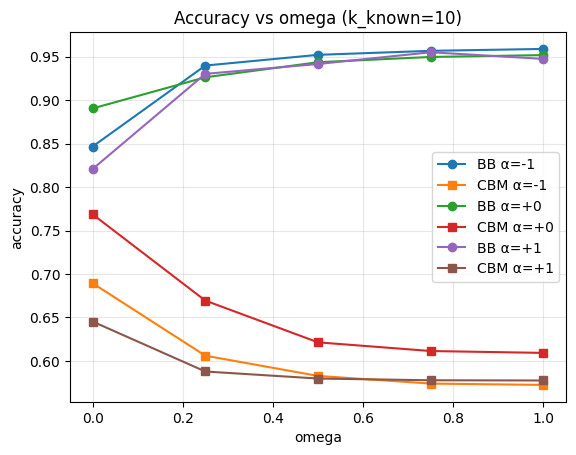

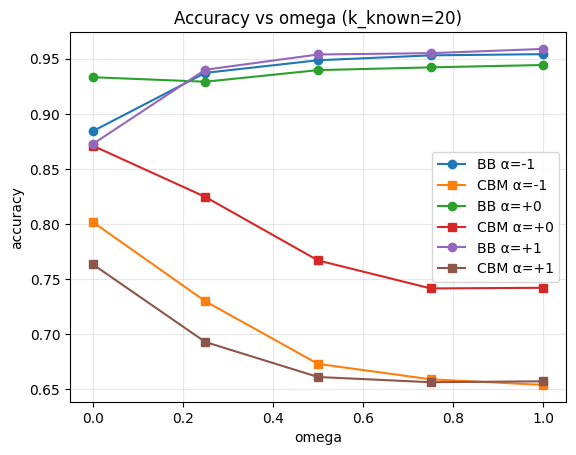

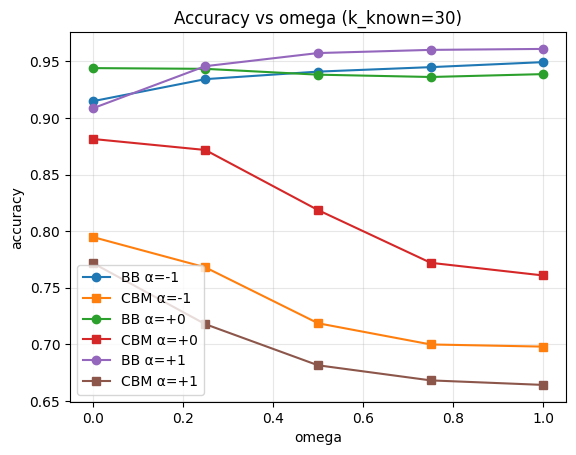

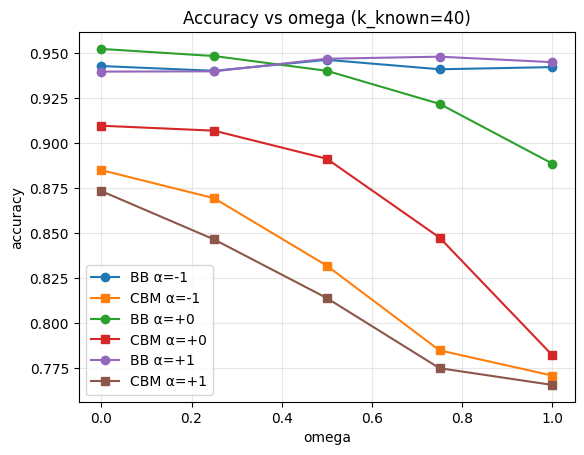

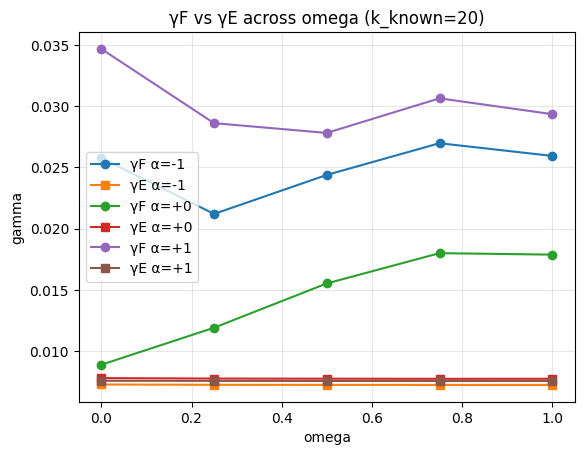

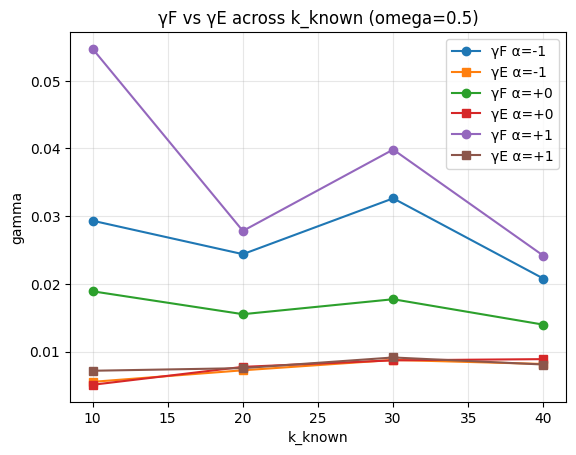

Wilcoxon γF: α=+1 vs α=-1 (paired): n=200  W=4804  p=1.5435e-10  median(diff)=0.00833664
Wilcoxon γE: α=+1 vs α=-1 (paired): n=200  W=7960  p=0.0107675  median(diff)=5.02934e-05
Paired conditions used: 200 (paired by seed,k_known,omega)


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# rows must be a list[dict] from your run_sweep(...)
assert "rows" in globals() and isinstance(rows, list) and len(rows) > 0, "Run the sweep first so `rows` exists."

df = pd.DataFrame(rows).copy()

# Normalise column names (your script uses F_pair_raw_mean/E_pair_raw_mean)
df = df.rename(columns={
    "F_pair_raw_mean": "gamma_F",
    "E_pair_raw_mean": "gamma_E",
})

# Ensure numeric
for c in ["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["seed","k_known","alpha","omega"])

# Aggregate across seeds (mean). If you only have seed=[1], this is identical to raw.
agg = (df.groupby(["k_known","alpha","omega"], as_index=False)
         .agg(bb_acc=("bb_acc","mean"),
              cbm_acc=("cbm_acc","mean"),
              gamma_F=("gamma_F","mean"),
              gamma_E=("gamma_E","mean")))

k_list = sorted(agg["k_known"].unique())
alphas = sorted(agg["alpha"].unique())

# ------------------------------------------------------------
# 1) One plot per k_known: 6 lines (BB + CBM for α=-1,0,+1) vs omega
# ------------------------------------------------------------
for k in k_list:
    sub = agg[agg["k_known"] == k].sort_values("omega")
    plt.figure()
    for a in alphas:
        s = sub[sub["alpha"] == a].sort_values("omega")
        if len(s) == 0:
            continue
        plt.plot(s["omega"], s["bb_acc"], marker="o", label=f"BB α={a:+.0f}")
        plt.plot(s["omega"], s["cbm_acc"], marker="s", label=f"CBM α={a:+.0f}")
    plt.xlabel("omega")
    plt.ylabel("accuracy")
    plt.title(f"Accuracy vs omega (k_known={k})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ------------------------------------------------------------
# 2a) Plot comparing gamma_F to gamma_E across omega for k_known=20 and α∈{-1,0,1}
# ------------------------------------------------------------
k_target = 20
sub = agg[agg["k_known"] == k_target].sort_values("omega")
plt.figure()
for a in alphas:
    s = sub[sub["alpha"] == a].sort_values("omega")
    if len(s) == 0:
        continue
    plt.plot(s["omega"], s["gamma_F"], marker="o", label=f"γF α={a:+.0f}")
    plt.plot(s["omega"], s["gamma_E"], marker="s", label=f"γE α={a:+.0f}")
plt.xlabel("omega")
plt.ylabel("gamma")
plt.title(f"γF vs γE across omega (k_known={k_target})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 2b) Plot comparing gamma_F to gamma_E across k_known for omega=0.5 and α∈{-1,0,1}
# ------------------------------------------------------------
omega_target = 0.5
sub = agg[np.isclose(agg["omega"], omega_target)].sort_values("k_known")
plt.figure()
for a in alphas:
    s = sub[sub["alpha"] == a].sort_values("k_known")
    if len(s) == 0:
        continue
    plt.plot(s["k_known"], s["gamma_F"], marker="o", label=f"γF α={a:+.0f}")
    plt.plot(s["k_known"], s["gamma_E"], marker="s", label=f"γE α={a:+.0f}")
plt.xlabel("k_known")
plt.ylabel("gamma")
plt.title(f"γF vs γE across k_known (omega={omega_target})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 3) Paired Wilcoxon tests: γF (α=+1 vs α=-1) across all (seed,k_known,omega), and same for γE
# ------------------------------------------------------------
from scipy.stats import wilcoxon

base_cols = ["seed","k_known","omega"]
pos = df[df["alpha"] == 1.0][base_cols + ["gamma_F","gamma_E"]].copy()
neg = df[df["alpha"] == -1.0][base_cols + ["gamma_F","gamma_E"]].copy()

paired = pd.merge(pos, neg, on=base_cols, suffixes=("_pos","_neg")).dropna()

def run_wilcoxon(x, y, label):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0:
        print(f"{label}: no paired data")
        return
    if np.allclose(x, y):
        print(f"{label}: all paired values are ~equal (differences ~0); Wilcoxon not informative.")
        return
    stat, p = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided", mode="auto")
    dif = x - y
    print(f"{label}: n={x.size}  W={stat:.6g}  p={p:.6g}  median(diff)={np.median(dif):.6g}")

run_wilcoxon(paired["gamma_F_pos"], paired["gamma_F_neg"], "Wilcoxon γF: α=+1 vs α=-1 (paired)")
run_wilcoxon(paired["gamma_E_pos"], paired["gamma_E_neg"], "Wilcoxon γE: α=+1 vs α=-1 (paired)")
print(f"Paired conditions used: {len(paired)} (paired by seed,k_known,omega)")


In [21]:
import pandas as pd

# Convert rows to DataFrame
df = pd.DataFrame(rows).copy()

# Export raw results
df.to_csv("results_updated_matching_B_new_code_acc_metrics.csv", index=False)
###i think no scale is better
print("Saved raw results to results_raw.csv")


Saved raw results to results_raw.csv


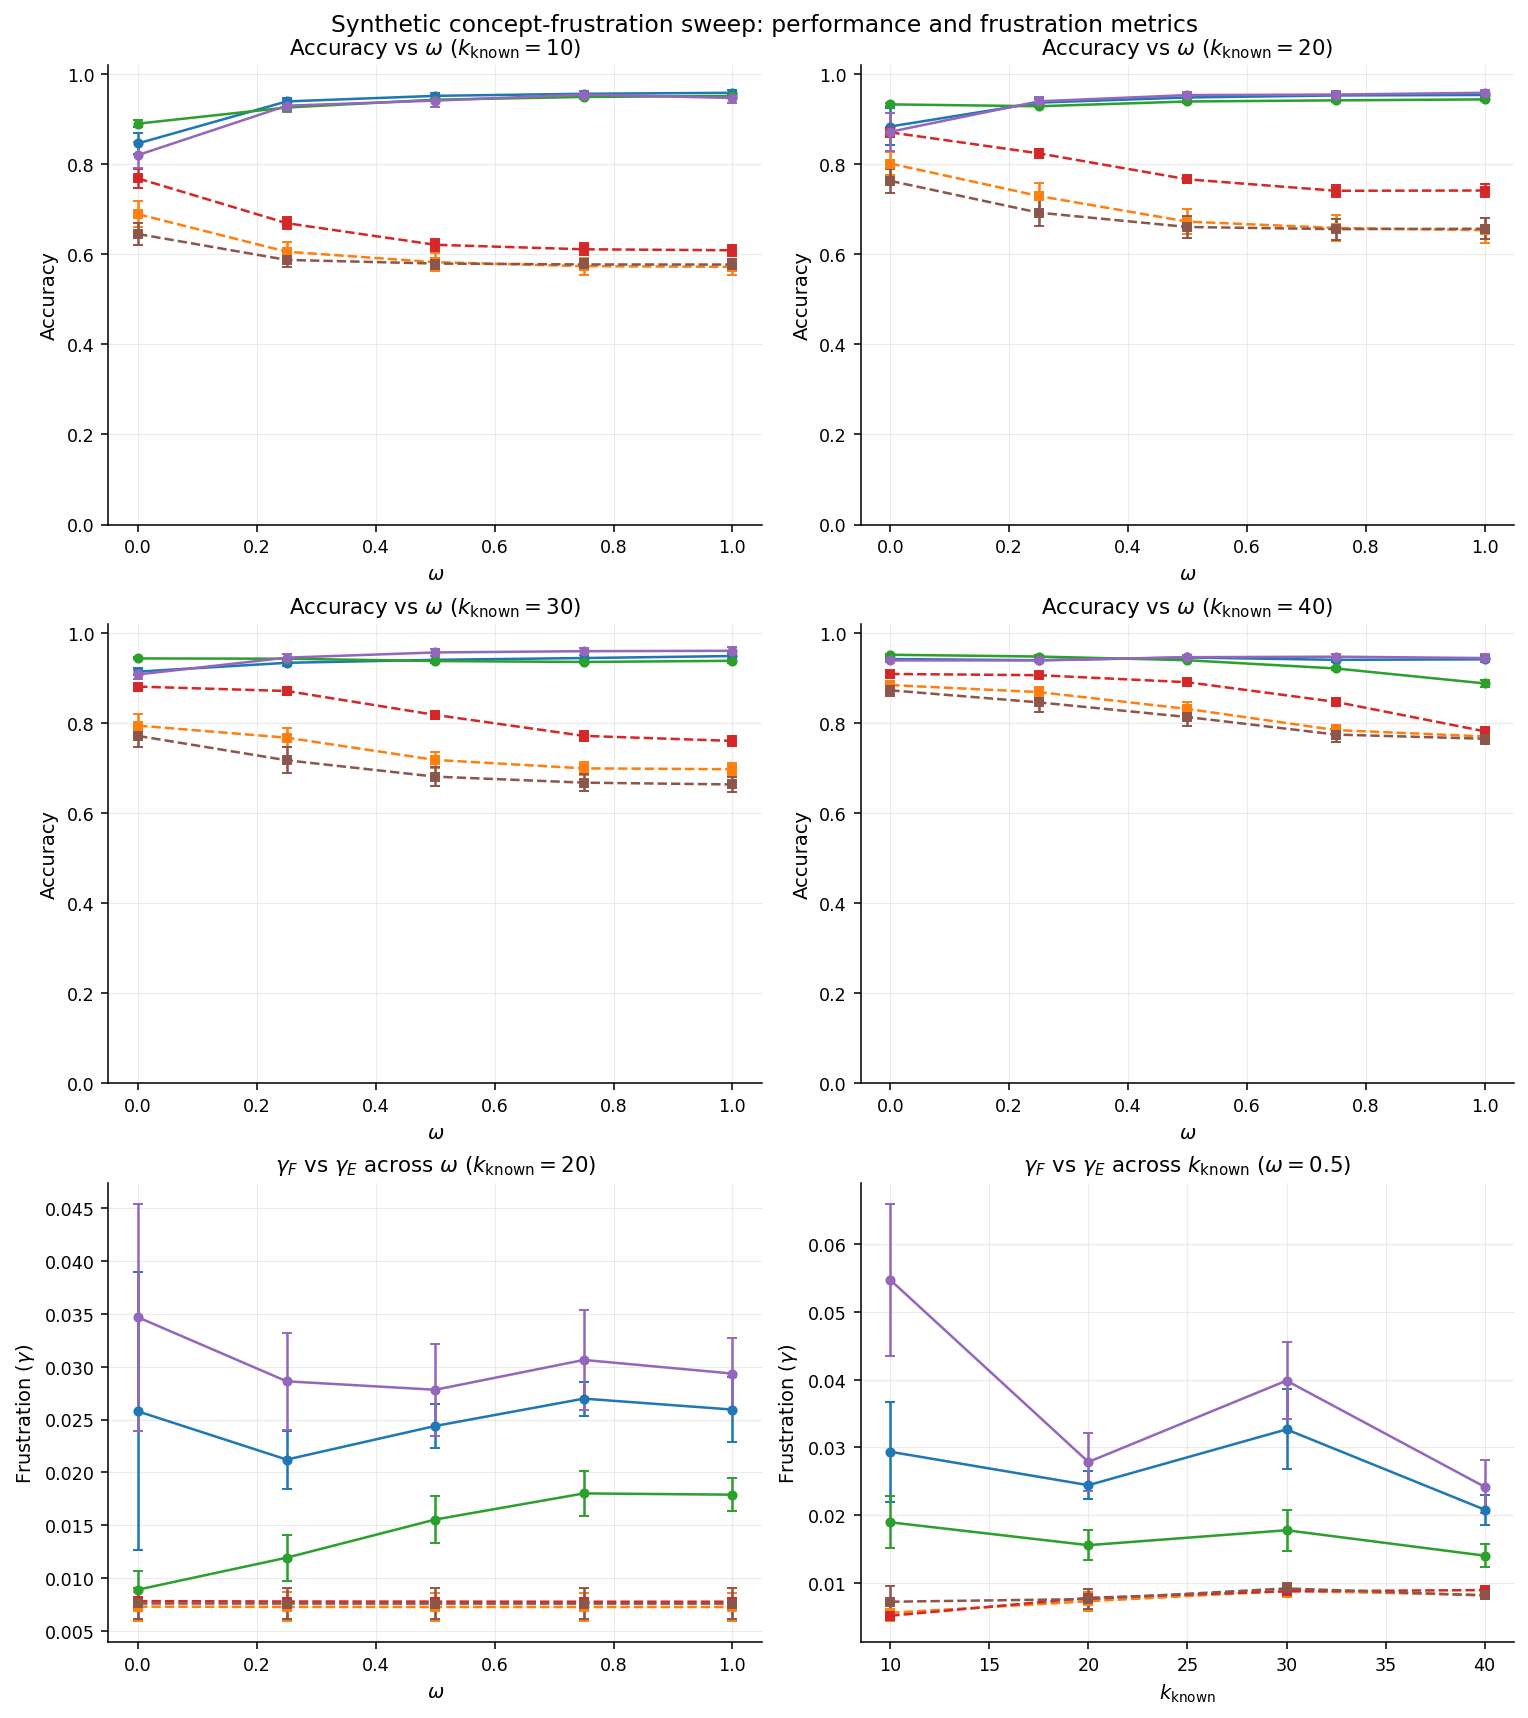

Saved PDF: publication_quality_6panel.pdf


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- REQUIREMENT: `rows` must already exist (list[dict]) from your run_sweep(...) ----
assert "rows" in globals() and isinstance(rows, list) and len(rows) > 0, "Run the sweep first so `rows` exists."

df = pd.DataFrame(rows).copy()

# Normalise column names (your script uses F_pair_raw_mean/E_pair_raw_mean)
df = df.rename(columns={
    "F_pair_raw_mean": "gamma_F",
    "E_pair_raw_mean": "gamma_E",
})

# Ensure numeric
for c in ["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]).copy()

# ---------- aggregate across seeds with mean + SEM (error bars) ----------
def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size <= 1:
        return 0.0
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

agg = (df.groupby(["k_known","alpha","omega"], as_index=False)
         .agg(
             bb_acc_mean=("bb_acc","mean"),
             bb_acc_sem=("bb_acc", sem),
             cbm_acc_mean=("cbm_acc","mean"),
             cbm_acc_sem=("cbm_acc", sem),
             gamma_F_mean=("gamma_F","mean"),
             gamma_F_sem=("gamma_F", sem),
             gamma_E_mean=("gamma_E","mean"),
             gamma_E_sem=("gamma_E", sem),
             n=("seed","nunique"),
         ))

k_list = sorted(agg["k_known"].unique())
alphas = sorted(agg["alpha"].unique())
# Prefer canonical ordering if present
canon = [-1.0, 0.0, 1.0]
alphas = [a for a in canon if any(np.isclose(agg["alpha"], a))] or alphas

# ---------- publication-ish matplotlib defaults (no manual colors) ----------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def alpha_label(a: float) -> str:
    if np.isclose(a, 1.0):  return r"$\alpha=+1$"
    if np.isclose(a, -1.0): return r"$\alpha=-1$"
    if np.isclose(a, 0.0):  return r"$\alpha=0$"
    return rf"$\alpha={a:.2g}$"

def add_errorbar_line(ax, x, y, yerr, marker, linestyle, label):
    ax.errorbar(
        np.asarray(x), np.asarray(y),
        yerr=np.asarray(yerr),
        marker=marker,
        linestyle=linestyle,
        linewidth=1.3,
        markersize=4.2,
        capsize=2.5,
        label=label,
    )

# ---------- build a SINGLE 6-panel figure (3x2) ----------
# Panels 1-4: Accuracy vs omega for each k_known (6 lines: BB+CBM for α=-1,0,+1)
# Panel 5: gamma_F & gamma_E vs omega for k_known=20 (α-stratified)
# Panel 6: gamma_F & gamma_E vs k_known for omega=0.5 (α-stratified)

# choose up to 4 k_known values for panels 1-4 (if you have >4, we take the first 4 sorted)
k_panels = k_list[:4]
while len(k_panels) < 4 and len(k_list) > 0:  # pad if fewer than 4
    k_panels.append(k_list[-1])

k_target = 20
omega_target = 0.5

fig, axes = plt.subplots(3, 2, figsize=(10.8, 12.0), constrained_layout=True)

# ---- Panels 1-4: accuracy vs omega ----
for idx, k in enumerate(k_panels):
    ax = axes[idx // 2, idx % 2]
    sub = agg[agg["k_known"] == k].sort_values("omega")

    for a in alphas:
        s = sub[np.isclose(sub["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        # BB (solid, circles)
        add_errorbar_line(
            ax,
            s["omega"], s["bb_acc_mean"], s["bb_acc_sem"],
            marker="o", linestyle="-",
            label=f"BB {alpha_label(a)}",
        )
        # CBM (dashed, squares)
        add_errorbar_line(
            ax,
            s["omega"], s["cbm_acc_mean"], s["cbm_acc_sem"],
            marker="s", linestyle="--",
            label=f"CBM {alpha_label(a)}",
        )

    ax.set_title(rf"Accuracy vs $\omega$ ($k_{{\mathrm{{known}}}}={int(k)}$)")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 5: gamma vs omega for k_known=20 ----
ax5 = axes[2, 0]
sub5 = agg[agg["k_known"] == k_target].sort_values("omega")
if len(sub5) == 0:
    ax5.text(0.5, 0.5, f"No data for k_known={k_target}", ha="center", va="center")
    ax5.set_axis_off()
else:
    for a in alphas:
        s = sub5[np.isclose(sub5["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax5.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $\omega$ ($k_{{\mathrm{{known}}}}={k_target}$)")
    ax5.set_xlabel(r"$\omega$")
    ax5.set_ylabel(r"Frustration ($\gamma$)")
    ax5.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 6: gamma vs k_known for omega=0.5 ----
ax6 = axes[2, 1]
sub6 = agg[np.isclose(agg["omega"], omega_target)].sort_values("k_known")
if len(sub6) == 0:
    ax6.text(0.5, 0.5, f"No data for omega={omega_target}", ha="center", va="center")
    ax6.set_axis_off()
else:
    for a in alphas:
        s = sub6[np.isclose(sub6["alpha"], a)].sort_values("k_known")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax6.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $k_{{\mathrm{{known}}}}$ ($\omega={omega_target}$)")
    ax6.set_xlabel(r"$k_{\mathrm{known}}$")
    ax6.set_ylabel(r"Frustration ($\gamma$)")
    ax6.grid(True, alpha=0.25, linewidth=0.6)


fig.suptitle("Synthetic concept-frustration sweep: performance and frustration metrics", y=1.01)

plt.show()

# ---- Export as vector PDF (editable text) ----
out_pdf = "publication_quality_6panel.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
print(f"Saved PDF: {out_pdf}")



In [25]:
######sequential CBM (predict concepts than predict task from predicted concepts)

import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# IMPORTANT: import your NEW generator (assignment-based, paper-consistent)
# Adjust this import path to wherever you put the new generator code.
# ============================================================
# from toy_generator import sample_B_components_for_seed, generate_toy_dataset_concepts_first


# ============================================================
# Models (unchanged)
# ============================================================

class BlackBoxMLP(nn.Module):
    """
    BB: x -> h -> logit
      z = W_H x + b_H          (pre-activation)
      h = ReLU(z)
      logit = w_l^T h + b_l
    """
    def __init__(self, r: int, hidden: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(r, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x, return_hidden: bool = False):
        z = self.fc1(x)
        h = self.act(z)
        logit = self.fc2(h).squeeze(-1)
        if return_hidden:
            return logit, z, h
        return logit


class LinearCBM(nn.Module):
    """
    Linear CBM on x:
      c_hat = Wc x + bc
      y_logit = wy^T c_hat + by
    """
    def __init__(self, xdim: int, k_known: int):
        super().__init__()
        self.concept = nn.Linear(xdim, k_known)
        self.task = nn.Linear(k_known, 1)

    def forward(self, x):
        c = self.concept(x)
        y = self.task(c).squeeze(-1)
        return c, y


class SparseAE(nn.Module):
    """
    SAE on x:
      s = ReLU(W x + b)
      x_hat = s D
    Decoder atoms D[j] live in SAME space as x.
    """
    def __init__(self, xdim: int, K: int):
        super().__init__()
        self.W = nn.Linear(xdim, K, bias=True)
        self.D = nn.Parameter(torch.randn(K, xdim) * 0.02)

    def forward(self, x):
        s = torch.relu(self.W(x))
        x_hat = s @ self.D
        return s, x_hat


# ============================================================
# Helpers (unchanged)
# ============================================================

@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y_true_np: np.ndarray) -> float:
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(np.int64)
    return float((preds == y_true_np).mean())


def train_test_split_indices(n: int, train_frac: float, rng: np.random.Generator):
    perm = rng.permutation(n)
    split = int(train_frac * n)
    return perm[:split], perm[split:]


# ============================================================
# Fisher helpers — compute probabilities + Fisher (unchanged)
# ============================================================

@torch.no_grad()
def bb_predict_proba(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu") -> np.ndarray:
    """Return p(y=1|x) for each row of X."""
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    logits = bb(Xt)
    return torch.sigmoid(logits).detach().cpu().numpy()


@torch.no_grad()
def compute_fisher_on_input_x(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu", ridge=1e-6):
    """
    Empirical Fisher in x-space:
      F ≈ (1/N) Σ p(1-p) g g^T
    where g(x)=∇_x logit = W_H^T (m(x) ⊙ w_l), m_i=1{(W_H x + b_H)_i>0}
    """
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)

    logits, z, _ = bb(Xt, return_hidden=True)   # z = W_H x + b_H
    p = torch.sigmoid(logits)                   # (N,)
    s = p * (1 - p)                             # (N,)
    m = (z > 0).float()                         # (N,H)

    W_H = bb.fc1.weight                         # (H,r)
    w_l = bb.fc2.weight.squeeze(0)              # (H,)

    U = m * w_l.unsqueeze(0)                    # (N,H)
    G = U @ W_H                                 # (N,r)

    F = (G.T @ (G * s.unsqueeze(1))) / float(X.shape[0])   # (r,r)
    F = F + ridge * torch.eye(F.shape[0], device=device)
    return F.cpu().numpy()


# ============================================================
# Training
# ============================================================

def train_bb_minibatch(
    X_tr, y_tr, X_te, y_te,
    *,
    hidden=128, epochs=30, batch_size=512, lr=1e-3, seed=0, device="cpu"
):
    torch.manual_seed(seed); np.random.seed(seed)
    r = X_tr.shape[1]
    model = BlackBoxMLP(r, hidden=hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, yb = Xt[b], yt[b]
            opt.zero_grad()
            loss = bce(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        acc_te = accuracy_from_logits(model(Xv), y_te)
    return model, acc_te


def train_cbm_hard_two_stage(
    X_tr, Ck_tr, y_tr,
    X_te, Ck_te, y_te,
    *,
    concept_epochs=30,
    task_epochs=30,
    batch_size=512,
    lr_concept=1e-3,
    lr_task=1e-3,
    seed=0,
    device="cpu",
):
    """
    HARD CBM:
      Stage A: train concept head only (MSE on concepts).
      Stage B: freeze concept head; train task head only (BCE on y) using predicted concepts.

    Returns: model, acc_test, concept_mse_test
    """
    torch.manual_seed(seed); np.random.seed(seed)

    xdim = X_tr.shape[1]
    k = Ck_tr.shape[1]
    model = LinearCBM(xdim, k).to(device)

    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    Ct = torch.tensor(Ck_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)

    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
    Cv = torch.tensor(Ck_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    # ---- Stage A: concept head only ----
    for p in model.task.parameters():
        p.requires_grad_(False)
    for p in model.concept.parameters():
        p.requires_grad_(True)

    opt_c = optim.Adam(model.concept.parameters(), lr=lr_concept)

    for _ in range(concept_epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, cb = Xt[b], Ct[b]
            opt_c.zero_grad()
            c_hat = model.concept(xb)
            loss = mse(c_hat, cb)
            loss.backward()
            opt_c.step()

    # ---- Stage B: task head only (freeze concept head) ----
    for p in model.concept.parameters():
        p.requires_grad_(False)
    for p in model.task.parameters():
        p.requires_grad_(True)

    opt_t = optim.Adam(model.task.parameters(), lr=lr_task)

    for _ in range(task_epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, yb = Xt[b], yt[b]
            opt_t.zero_grad()
            with torch.no_grad():
                c_hat = model.concept(xb)  # frozen + no grad
            logit = model.task(c_hat).squeeze(-1)
            loss = bce(logit, yb)
            loss.backward()
            opt_t.step()

    # ---- Eval ----
    model.eval()
    with torch.no_grad():
        c_hat_te = model.concept(Xv)
        logit_te = model.task(c_hat_te).squeeze(-1)
        acc_te = accuracy_from_logits(logit_te, y_te)
        mse_te = float(((c_hat_te - Cv)**2).mean().cpu().item())

    return model, acc_te, mse_te


def train_sae_minibatch(X_tr, *, K=60, epochs=60, batch_size=512, lr=2e-3, l1=1e-3, seed=0, device="cpu"):
    torch.manual_seed(seed); np.random.seed(seed)
    xdim = X_tr.shape[1]
    model = SparseAE(xdim, K).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb = Xt[b]
            opt.zero_grad()
            s_code, xhat = model(xb)
            loss = ((xhat - xb)**2).mean() + l1 * s_code.abs().mean()
            loss.backward()
            opt.step()

    return model


# ============================================================
# Geometry: Fisher cosine matrix AND Euclidean cosine matrix
# ============================================================

def fisher_cosine_matrix(W: np.ndarray, D: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    DFD = np.einsum("jh,hk,jk->j", D, Fsym, D)
    Wn = np.sqrt(np.maximum(WFW, eps))
    Dn = np.sqrt(np.maximum(DFD, eps))
    num = W @ Fsym @ D.T
    return num / (Wn[:, None] * Dn[None, :] + eps)


def euclid_cosine_matrix(W: np.ndarray, D: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1, keepdims=True) + eps)
    Dn = np.sqrt(np.sum(D * D, axis=1, keepdims=True) + eps)
    return (W @ D.T) / (Wn @ Dn.T)


def fisher_cosine_self(W: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    Wn = np.sqrt(np.maximum(WFW, eps))
    num = W @ Fsym @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


def euclid_cosine_self(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1) + eps)
    num = W @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


# ============================================================
# Frustration metric
# ============================================================

def pair_raw_frustration_mean(S: np.ndarray, Z: np.ndarray) -> float:
    k, K = S.shape
    if k < 2:
        return 0.0

    scores = []
    for l in range(k):
        for r in range(l + 1, k):
            z = float(Z[l, r])
            if z == 0.0:
                scores.append(0.0)
                continue
            prod = S[l, :] * S[r, :]
            zsign = np.sign(z)
            psign = np.sign(prod)
            contr = (psign != 0) & (psign != zsign)
            if not np.any(contr):
                scores.append(0.0)
            else:
                scores.append(float(np.max(np.abs(prod[contr]))))
    return float(np.mean(scores)) if scores else 0.0


# ============================================================
# Frobenius metrics (G)
# ============================================================

def frob_norm(A: np.ndarray) -> float:
    return float(np.sqrt(np.sum(A * A)))

def frob_abs_rel(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> dict:
    diff = A - B
    abs_f = frob_norm(diff)
    denom = frob_norm(A) + eps
    rel_f = abs_f / denom
    return {"frob_abs": float(abs_f), "frob_rel": float(rel_f)}


# ============================================================
# Predicted concept covariance vs generator B_known (beta)
# ============================================================

def cov_matrix(X: np.ndarray) -> np.ndarray:
    return np.cov(X, rowvar=False, bias=False)


# ============================================================
# T1..T4 terms from generator objects (unchanged)
# ============================================================

def compute_T_terms(
    *,
    B_known: np.ndarray,
    B_temp: np.ndarray,
    B_full: np.ndarray,
    w_star: np.ndarray,
    k_known: int,
    eps: float = 1e-12,
) -> dict:
    k_total = B_full.shape[0]
    k_unk = k_total - k_known
    if k_unk <= 0:
        return {"T1": 0.0, "T2": 0.0, "T3": 0.0, "T4": 0.0}

    psi_k = np.asarray(w_star[:k_known], dtype=np.float64)
    psi_u = np.asarray(w_star[k_known:], dtype=np.float64)

    Bkk = np.asarray(B_known, dtype=np.float64)
    Bku = np.asarray(B_full[:k_known, k_known:], dtype=np.float64)
    Buk = Bku.T
    Btemp = np.asarray(B_temp, dtype=np.float64)

    Binv = np.linalg.inv(Bkk + eps * np.eye(k_known))

    T1 = float(psi_k.T @ Bkk @ psi_k)
    T2 = float(psi_k.T @ Bku @ psi_u)

    bridge = Buk @ Binv @ Bku
    T3 = float(psi_u.T @ bridge @ psi_u)

    T4 = float(psi_u.T @ Btemp @ psi_u)

    return {"T1": T1, "T2": T2, "T3": T3, "T4": T4}


# ============================================================
# One run
# ============================================================

def run_one(
    *,
    alpha: float,
    omega: float,
    seed: int,
    k_known: int,
    B_components,
    device="cpu",
    sigma_x: float = 0.3,
    sigma_y: float = 1.5,
    p_lo: float = 0.4,
    p_hi: float = 0.6,
    min_keep: int = 50,
    r: int = 64,
    k_total: int = 50,
    n: int = 8000,
    K_sae: int = 60,
):
    # Generate data using NEW generator (assignment-based)
    X, C, y, B, A, w, w_star, comps_out = generate_toy_dataset_concepts_first(
        n=int(n), r=int(r), k=int(k_total), k_known=int(k_known),
        sigma_x=float(sigma_x),
        sigma_y=float(sigma_y),
        omega=float(omega),
        seed=int(seed),
        alpha=float(alpha),
        A_scale="none",
        B_components=B_components,
    )

    B = np.asarray(B, dtype=np.float64)
    w_star = np.asarray(w_star, dtype=np.float64)

    # B_components layout for the new generator:
    #   (B_known, B_temp, assignment, alpha_strength)
    B_known = np.asarray(B_components[0], dtype=np.float64)
    B_temp  = np.asarray(B_components[1], dtype=np.float64)

    rng = np.random.default_rng(seed)
    tr_idx, te_idx = train_test_split_indices(len(X), 0.75, rng)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]
    Ck_tr, Ck_te = C[tr_idx, :k_known], C[te_idx, :k_known]

    # (1) BB
    bb, bb_acc = train_bb_minibatch(
        X_tr, y_tr, X_te, y_te,
        hidden=128, epochs=30, batch_size=512, lr=1e-3,
        seed=seed, device=device
    )

    # (2) Fisher on uncertain subset
    p_lo_use, p_hi_use = (p_lo, p_hi) if p_lo < p_hi else (p_hi, p_lo)
    p_tr = bb_predict_proba(bb, X_tr, device=device)
    keep = np.where((p_tr >= p_lo_use) & (p_tr <= p_hi_use))[0]
    if keep.size < min_keep:
        order = np.argsort(np.abs(p_tr - 0.5))
        keep = order[:min_keep]
    F = compute_fisher_on_input_x(bb, X_tr[keep], device=device, ridge=1e-6)

    # (3) HARD CBM (2-stage: concepts -> freeze -> task)
    cbm, cbm_acc, cbm_mse = train_cbm_hard_two_stage(
        X_tr, Ck_tr, y_tr,
        X_te, Ck_te, y_te,
        concept_epochs=30,
        task_epochs=30,
        batch_size=512,
        lr_concept=1e-3,
        lr_task=1e-3,
        seed=seed,
        device=device
    )
    Wc = cbm.concept.weight.detach().cpu().numpy()

    with torch.no_grad():
        Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
        c_hat_te = cbm.concept(Xv)     # concept head only
        C_hat_te = c_hat_te.detach().cpu().numpy()

    # (4) SAE
    sae = train_sae_minibatch(
        X_tr,
        K=K_sae, epochs=60, batch_size=512, lr=2e-3, l1=1e-3,
        seed=seed, device=device
    )
    D = sae.D.detach().cpu().numpy()

    # (5) S + Z matrices
    S_f = fisher_cosine_matrix(Wc, D, F)
    S_e = euclid_cosine_matrix(Wc, D)

    Z_f = fisher_cosine_self(Wc, F)
    Z_e = euclid_cosine_self(Wc)

    # (6) gamma metrics
    gamma_F = pair_raw_frustration_mean(S_f, Z_f)
    gamma_E = pair_raw_frustration_mean(S_e, Z_e)

    # (7) geometry difference (G)
    Sd = frob_abs_rel(S_f, S_e)

    # (8) covariance faithfulness (beta)
    Cov_hat = cov_matrix(C_hat_te)
    cov_diff = frob_abs_rel(Cov_hat, B_known)

    # (9) T terms
    T = compute_T_terms(
        B_known=B_known,
        B_temp=B_temp,
        B_full=B,
        w_star=w_star,
        k_known=k_known,
    )

    return {
        "seed": int(seed),
        "k_known": int(k_known),
        "k_total": int(k_total),
        "alpha": float(alpha),
        "omega": float(omega),

        "n": int(n),
        "r": int(r),
        "sigma_x": float(sigma_x),
        "sigma_y": float(sigma_y),

        "p_lo": float(p_lo_use),
        "p_hi": float(p_hi_use),
        "F_keep_n": int(len(keep)),

        "bb_acc": float(bb_acc),
        "cbm_acc": float(cbm_acc),
        "cbm_mse": float(cbm_mse),

        "F_pair_raw_mean": float(gamma_F),
        "E_pair_raw_mean": float(gamma_E),

        "S_frob_abs": float(Sd["frob_abs"]),
        "S_frob_rel": float(Sd["frob_rel"]),

        "Cov_frob_abs": float(cov_diff["frob_abs"]),
        "Cov_frob_rel": float(cov_diff["frob_rel"]),

        "T1": float(T["T1"]),
        "T2": float(T["T2"]),
        "T3": float(T["T3"]),
        "T4": float(T["T4"]),
    }


# ============================================================
# Sweep runner (alpha fixed to {-1,0,1})
# ============================================================

def run_sweep(
    *,
    omega_list,
    k_known_list,
    seeds,
    device="cpu",
    sigma_x=0.3,
    sigma_y=0.6,
    p_lo=0.2,
    p_hi=0.8,
    min_keep=200,
    r=64,
    k_total=50,
    n=8000,
    K_sae=60,
    alpha_strength=1.0,
):
    rows = []
    alphas = (-1.0, 0.0, +1.0)

    total = len(seeds) * len(k_known_list) * len(omega_list) * len(alphas)
    t = 0

    for seed in seeds:
        for k_known in k_known_list:
            B_components = sample_B_components_for_seed(
                k=int(k_total),
                k_known=int(k_known),
                seed=int(seed),
                alpha_strength=float(alpha_strength),
            )

            for omega in omega_list:
                for alpha in alphas:
                    t += 1
                    out = run_one(
                        alpha=alpha,
                        omega=omega,
                        seed=seed,
                        k_known=k_known,
                        B_components=B_components,
                        device=device,
                        sigma_x=sigma_x,
                        sigma_y=sigma_y,
                        p_lo=p_lo,
                        p_hi=p_hi,
                        min_keep=min_keep,
                        r=r,
                        k_total=k_total,
                        n=n,
                        K_sae=K_sae,
                    )
                    rows.append(out)

                    print(
                        f"[{t:04d}/{total:04d}] "
                        f"seed={out['seed']:2d} k={out['k_known']:2d} "
                        f"α={out['alpha']:+.0f} ω={out['omega']:.2f} keep={out['F_keep_n']:4d} | "
                        f"bb={out['bb_acc']:.3f} cbm={out['cbm_acc']:.3f} mse={out['cbm_mse']:.3f} | "
                        f"γF={out['F_pair_raw_mean']:.3f} γE={out['E_pair_raw_mean']:.3f} | "
                        f"Grel={out['S_frob_rel']:.3f} βrel={out['Cov_frob_rel']:.3f} | "
                        f"T1={out['T1']:.2e} T2={out['T2']:.2e} T3={out['T3']:.2e} T4={out['T4']:.2e}"
                    )

    return rows


# ============================================================
# Main (no saving required)
# ============================================================

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    seeds = [1,2,3,4,5,6,7,8,9,10]
    omega_list = [0.0, 0.25, 0.5, 0.75, 1.0]
    k_known_list = [10, 20, 30, 40]

    sigma_x = 0.3
    sigma_y = 1.5

    p_lo, p_hi = 0.2, 0.8
    min_keep = 200

    r = 64
    k_total = 50
    n = 8000
    K_sae = 60

    alpha_strength = 1.0

    rows = run_sweep(
        omega_list=omega_list,
        k_known_list=k_known_list,
        seeds=seeds,
        device=device,
        sigma_x=sigma_x,
        sigma_y=sigma_y,
        p_lo=p_lo,
        p_hi=p_hi,
        min_keep=min_keep,
        r=r,
        k_total=k_total,
        n=n,
        K_sae=K_sae,
        alpha_strength=alpha_strength,
    )

    print("\nDone. (Not saving output files as requested.)")


[0001/0600] seed= 1 k=10 α=-1 ω=0.00 keep= 871 | bb=0.875 cbm=0.801 mse=6.255 | γF=0.027 γE=0.003 | Grel=0.990 βrel=0.546 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0002/0600] seed= 1 k=10 α=+0 ω=0.00 keep= 692 | bb=0.887 cbm=0.819 mse=2.338 | γF=0.002 γE=0.004 | Grel=0.991 βrel=0.265 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0003/0600] seed= 1 k=10 α=+1 ω=0.00 keep= 967 | bb=0.866 cbm=0.699 mse=16.886 | γF=0.044 γE=0.003 | Grel=0.997 βrel=0.716 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0004/0600] seed= 1 k=10 α=-1 ω=0.25 keep= 336 | bb=0.935 cbm=0.636 mse=6.255 | γF=0.043 γE=0.003 | Grel=0.998 βrel=0.546 | T1=2.50e+01 T2=5.63e+00 T3=5.39e+01 T4=8.67e+01
[0005/0600] seed= 1 k=10 α=+0 ω=0.25 keep= 352 | bb=0.927 cbm=0.619 mse=2.338 | γF=0.027 γE=0.004 | Grel=0.994 βrel=0.265 | T1=2.50e+01 T2=0.00e+00 T3=0.00e+00 T4=8.67e+01
[0006/0600] seed= 1 k=10 α=+1 ω=0.25 keep= 200 | bb=0.960 cbm=0.566 mse=16.886 | γF=0.044 γE=0.003 | Grel=1.002 βrel=0.716 | T1=2.50e+01 T2

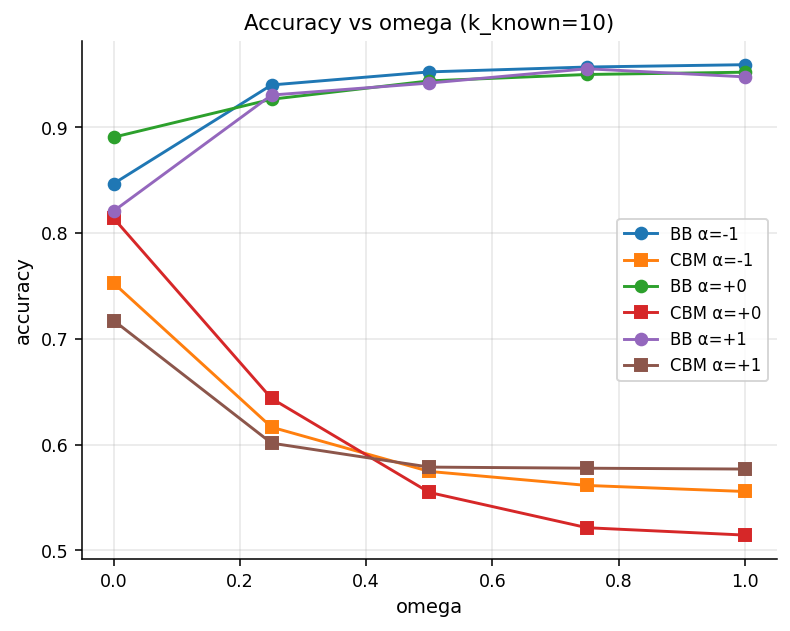

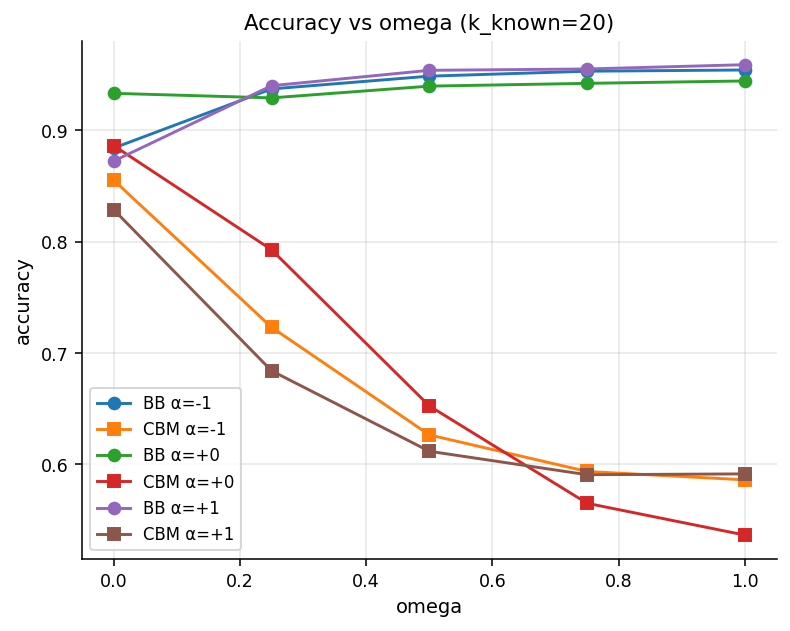

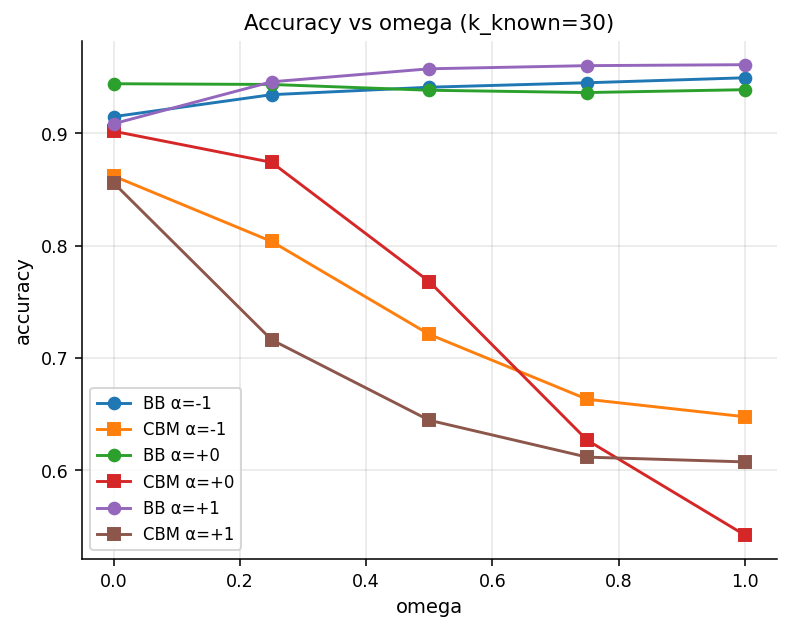

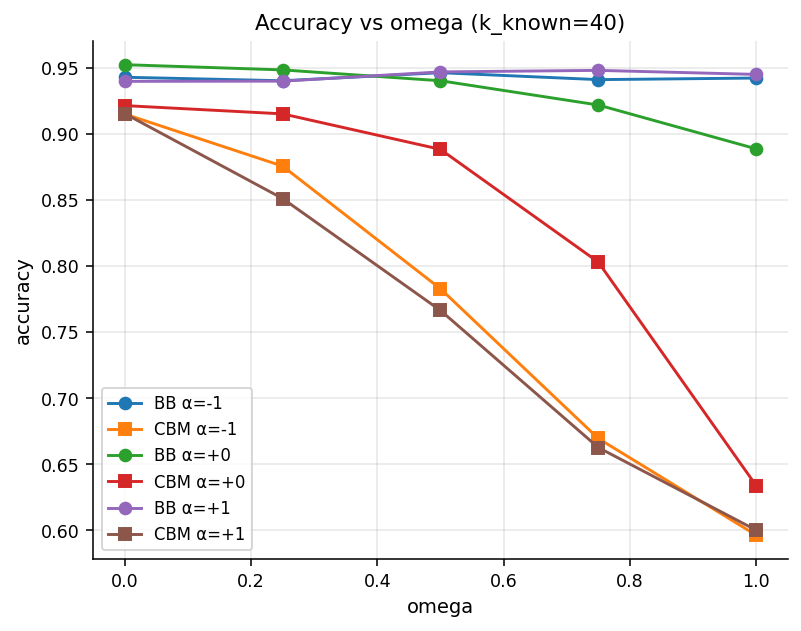

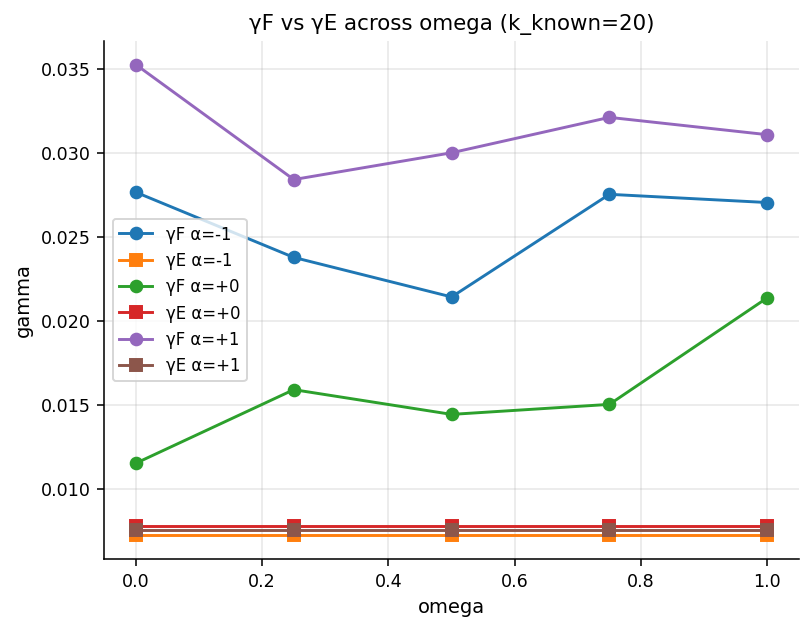

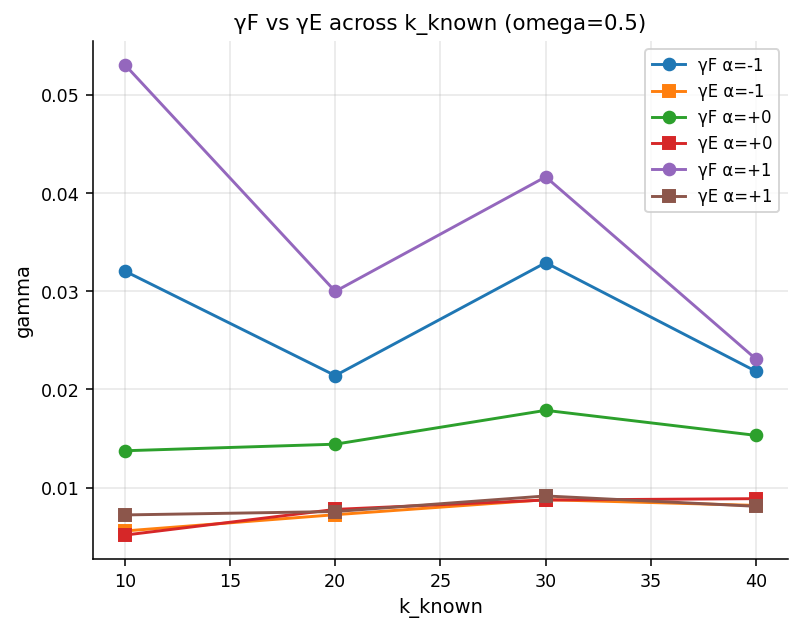

Wilcoxon γF: α=+1 vs α=-1 (paired): n=200  W=4749  p=9.92283e-11  median(diff)=0.00770737
Wilcoxon γE: α=+1 vs α=-1 (paired): n=200  W=8020  p=0.0132444  median(diff)=6.44946e-05
Paired conditions used: 200 (paired by seed,k_known,omega)


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# rows must be a list[dict] from your run_sweep(...)
assert "rows" in globals() and isinstance(rows, list) and len(rows) > 0, "Run the sweep first so `rows` exists."

df = pd.DataFrame(rows).copy()

# Normalise column names (your script uses F_pair_raw_mean/E_pair_raw_mean)
df = df.rename(columns={
    "F_pair_raw_mean": "gamma_F",
    "E_pair_raw_mean": "gamma_E",
})

# Ensure numeric
for c in ["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["seed","k_known","alpha","omega"])

# Aggregate across seeds (mean). If you only have seed=[1], this is identical to raw.
agg = (df.groupby(["k_known","alpha","omega"], as_index=False)
         .agg(bb_acc=("bb_acc","mean"),
              cbm_acc=("cbm_acc","mean"),
              gamma_F=("gamma_F","mean"),
              gamma_E=("gamma_E","mean")))

k_list = sorted(agg["k_known"].unique())
alphas = sorted(agg["alpha"].unique())

# ------------------------------------------------------------
# 1) One plot per k_known: 6 lines (BB + CBM for α=-1,0,+1) vs omega
# ------------------------------------------------------------
for k in k_list:
    sub = agg[agg["k_known"] == k].sort_values("omega")
    plt.figure()
    for a in alphas:
        s = sub[sub["alpha"] == a].sort_values("omega")
        if len(s) == 0:
            continue
        plt.plot(s["omega"], s["bb_acc"], marker="o", label=f"BB α={a:+.0f}")
        plt.plot(s["omega"], s["cbm_acc"], marker="s", label=f"CBM α={a:+.0f}")
    plt.xlabel("omega")
    plt.ylabel("accuracy")
    plt.title(f"Accuracy vs omega (k_known={k})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ------------------------------------------------------------
# 2a) Plot comparing gamma_F to gamma_E across omega for k_known=20 and α∈{-1,0,1}
# ------------------------------------------------------------
k_target = 20
sub = agg[agg["k_known"] == k_target].sort_values("omega")
plt.figure()
for a in alphas:
    s = sub[sub["alpha"] == a].sort_values("omega")
    if len(s) == 0:
        continue
    plt.plot(s["omega"], s["gamma_F"], marker="o", label=f"γF α={a:+.0f}")
    plt.plot(s["omega"], s["gamma_E"], marker="s", label=f"γE α={a:+.0f}")
plt.xlabel("omega")
plt.ylabel("gamma")
plt.title(f"γF vs γE across omega (k_known={k_target})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 2b) Plot comparing gamma_F to gamma_E across k_known for omega=0.5 and α∈{-1,0,1}
# ------------------------------------------------------------
omega_target = 0.5
sub = agg[np.isclose(agg["omega"], omega_target)].sort_values("k_known")
plt.figure()
for a in alphas:
    s = sub[sub["alpha"] == a].sort_values("k_known")
    if len(s) == 0:
        continue
    plt.plot(s["k_known"], s["gamma_F"], marker="o", label=f"γF α={a:+.0f}")
    plt.plot(s["k_known"], s["gamma_E"], marker="s", label=f"γE α={a:+.0f}")
plt.xlabel("k_known")
plt.ylabel("gamma")
plt.title(f"γF vs γE across k_known (omega={omega_target})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 3) Paired Wilcoxon tests: γF (α=+1 vs α=-1) across all (seed,k_known,omega), and same for γE
# ------------------------------------------------------------
from scipy.stats import wilcoxon

base_cols = ["seed","k_known","omega"]
pos = df[df["alpha"] == 1.0][base_cols + ["gamma_F","gamma_E"]].copy()
neg = df[df["alpha"] == -1.0][base_cols + ["gamma_F","gamma_E"]].copy()

paired = pd.merge(pos, neg, on=base_cols, suffixes=("_pos","_neg")).dropna()

def run_wilcoxon(x, y, label):
    x = np.asarray(x); y = np.asarray(y)
    if x.size == 0:
        print(f"{label}: no paired data")
        return
    if np.allclose(x, y):
        print(f"{label}: all paired values are ~equal (differences ~0); Wilcoxon not informative.")
        return
    stat, p = wilcoxon(x, y, zero_method="wilcox", alternative="two-sided", mode="auto")
    dif = x - y
    print(f"{label}: n={x.size}  W={stat:.6g}  p={p:.6g}  median(diff)={np.median(dif):.6g}")

run_wilcoxon(paired["gamma_F_pos"], paired["gamma_F_neg"], "Wilcoxon γF: α=+1 vs α=-1 (paired)")
run_wilcoxon(paired["gamma_E_pos"], paired["gamma_E_neg"], "Wilcoxon γE: α=+1 vs α=-1 (paired)")
print(f"Paired conditions used: {len(paired)} (paired by seed,k_known,omega)")


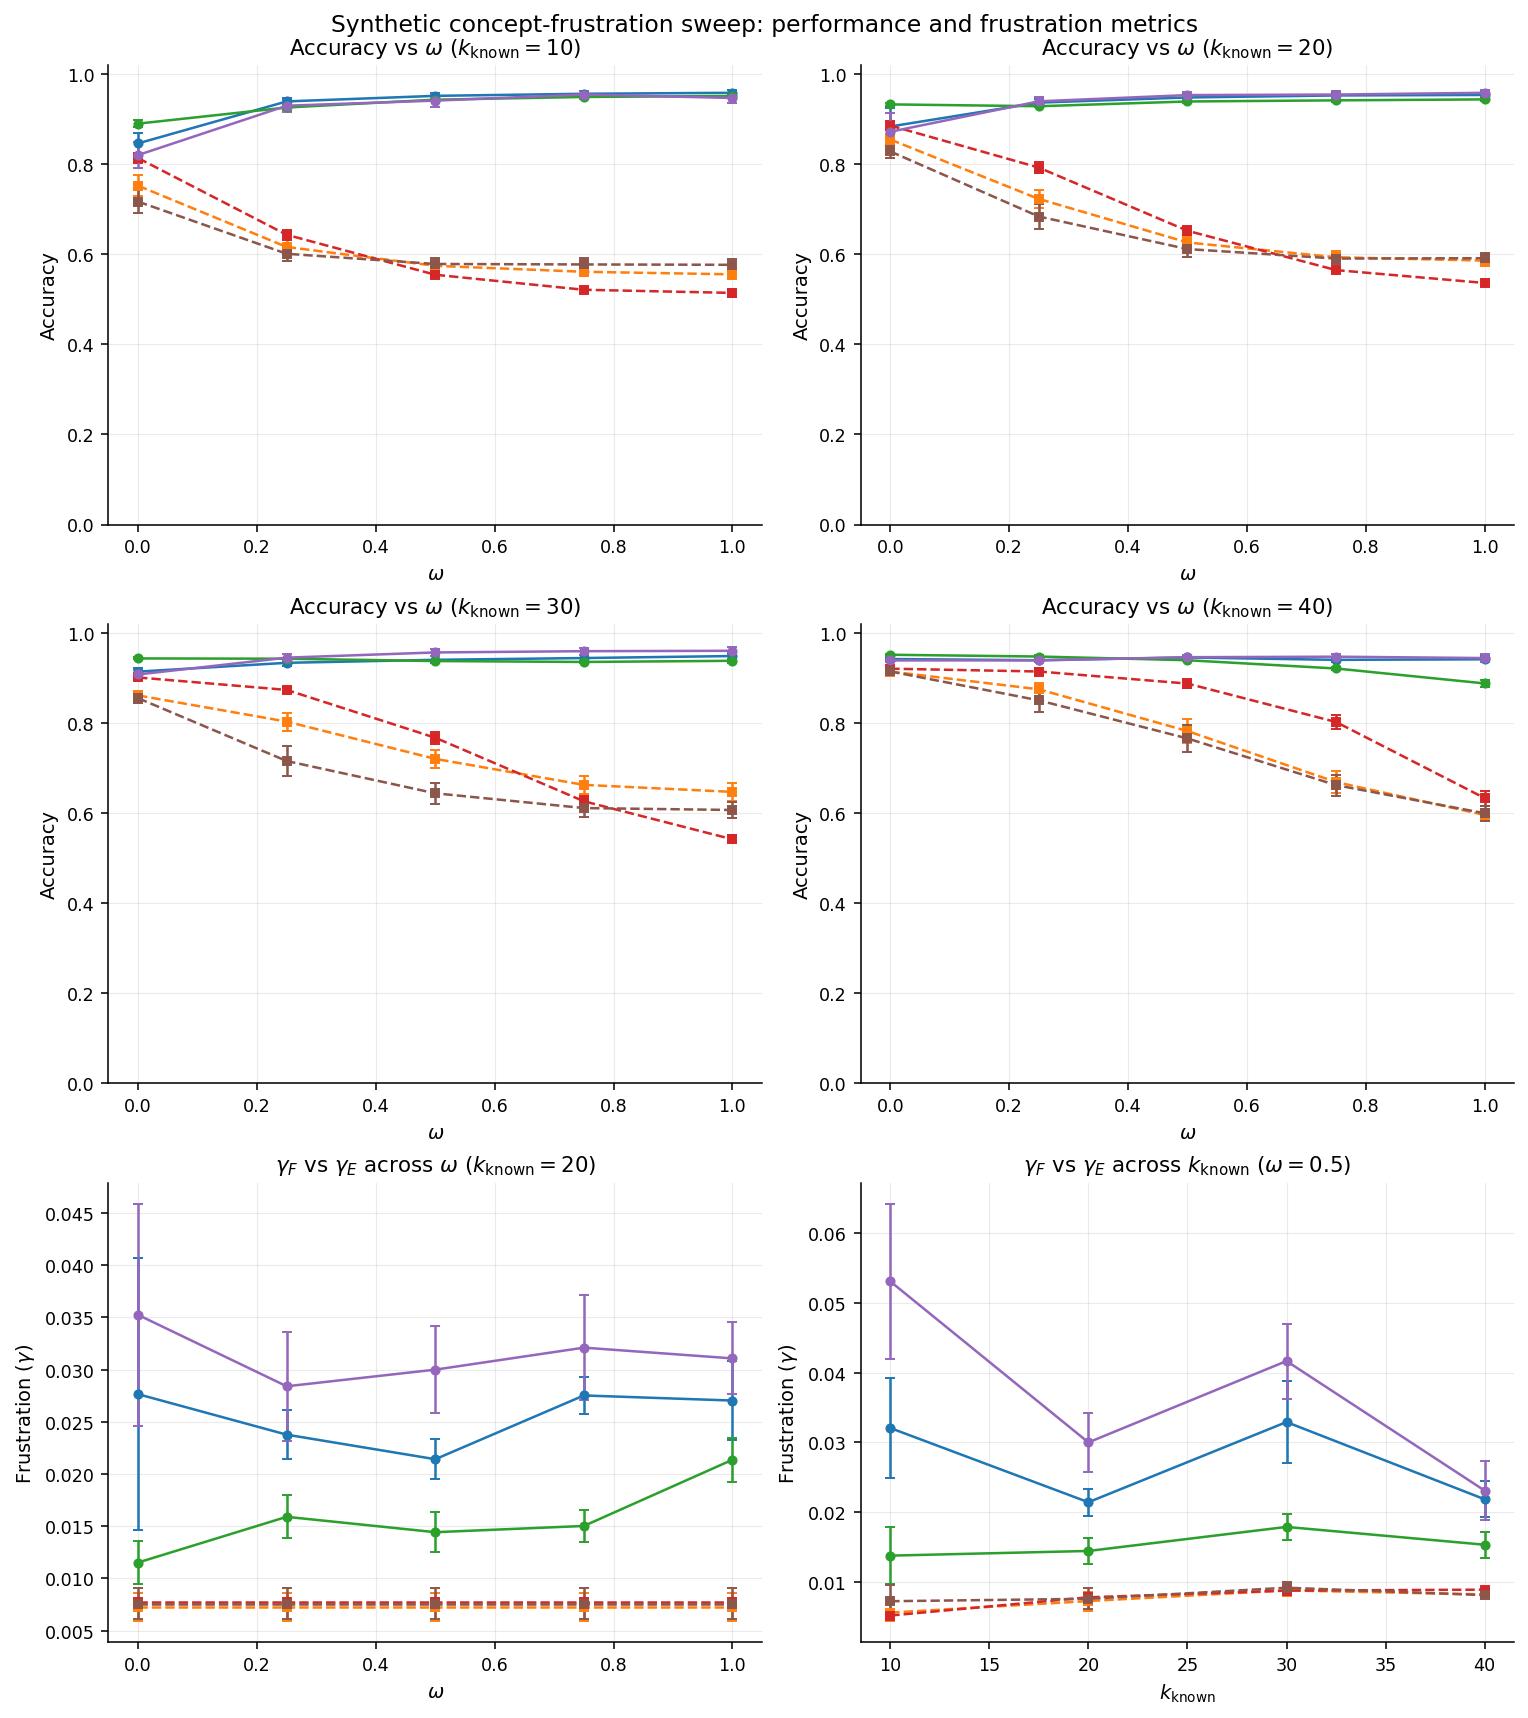

Saved PDF: publication_quality_6panel_hard_CBM.pdf


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- REQUIREMENT: `rows` must already exist (list[dict]) from your run_sweep(...) ----
assert "rows" in globals() and isinstance(rows, list) and len(rows) > 0, "Run the sweep first so `rows` exists."

df = pd.DataFrame(rows).copy()

# Normalise column names (your script uses F_pair_raw_mean/E_pair_raw_mean)
df = df.rename(columns={
    "F_pair_raw_mean": "gamma_F",
    "E_pair_raw_mean": "gamma_E",
})

# Ensure numeric
for c in ["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]).copy()

# ---------- aggregate across seeds with mean + SEM (error bars) ----------
def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size <= 1:
        return 0.0
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

agg = (df.groupby(["k_known","alpha","omega"], as_index=False)
         .agg(
             bb_acc_mean=("bb_acc","mean"),
             bb_acc_sem=("bb_acc", sem),
             cbm_acc_mean=("cbm_acc","mean"),
             cbm_acc_sem=("cbm_acc", sem),
             gamma_F_mean=("gamma_F","mean"),
             gamma_F_sem=("gamma_F", sem),
             gamma_E_mean=("gamma_E","mean"),
             gamma_E_sem=("gamma_E", sem),
             n=("seed","nunique"),
         ))

k_list = sorted(agg["k_known"].unique())
alphas = sorted(agg["alpha"].unique())
# Prefer canonical ordering if present
canon = [-1.0, 0.0, 1.0]
alphas = [a for a in canon if any(np.isclose(agg["alpha"], a))] or alphas

# ---------- publication-ish matplotlib defaults (no manual colors) ----------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def alpha_label(a: float) -> str:
    if np.isclose(a, 1.0):  return r"$\alpha=+1$"
    if np.isclose(a, -1.0): return r"$\alpha=-1$"
    if np.isclose(a, 0.0):  return r"$\alpha=0$"
    return rf"$\alpha={a:.2g}$"

def add_errorbar_line(ax, x, y, yerr, marker, linestyle, label):
    ax.errorbar(
        np.asarray(x), np.asarray(y),
        yerr=np.asarray(yerr),
        marker=marker,
        linestyle=linestyle,
        linewidth=1.3,
        markersize=4.2,
        capsize=2.5,
        label=label,
    )

# ---------- build a SINGLE 6-panel figure (3x2) ----------
# Panels 1-4: Accuracy vs omega for each k_known (6 lines: BB+CBM for α=-1,0,+1)
# Panel 5: gamma_F & gamma_E vs omega for k_known=20 (α-stratified)
# Panel 6: gamma_F & gamma_E vs k_known for omega=0.5 (α-stratified)

# choose up to 4 k_known values for panels 1-4 (if you have >4, we take the first 4 sorted)
k_panels = k_list[:4]
while len(k_panels) < 4 and len(k_list) > 0:  # pad if fewer than 4
    k_panels.append(k_list[-1])

k_target = 20
omega_target = 0.5

fig, axes = plt.subplots(3, 2, figsize=(10.8, 12.0), constrained_layout=True)

# ---- Panels 1-4: accuracy vs omega ----
for idx, k in enumerate(k_panels):
    ax = axes[idx // 2, idx % 2]
    sub = agg[agg["k_known"] == k].sort_values("omega")

    for a in alphas:
        s = sub[np.isclose(sub["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        # BB (solid, circles)
        add_errorbar_line(
            ax,
            s["omega"], s["bb_acc_mean"], s["bb_acc_sem"],
            marker="o", linestyle="-",
            label=f"BB {alpha_label(a)}",
        )
        # CBM (dashed, squares)
        add_errorbar_line(
            ax,
            s["omega"], s["cbm_acc_mean"], s["cbm_acc_sem"],
            marker="s", linestyle="--",
            label=f"CBM {alpha_label(a)}",
        )

    ax.set_title(rf"Accuracy vs $\omega$ ($k_{{\mathrm{{known}}}}={int(k)}$)")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 5: gamma vs omega for k_known=20 ----
ax5 = axes[2, 0]
sub5 = agg[agg["k_known"] == k_target].sort_values("omega")
if len(sub5) == 0:
    ax5.text(0.5, 0.5, f"No data for k_known={k_target}", ha="center", va="center")
    ax5.set_axis_off()
else:
    for a in alphas:
        s = sub5[np.isclose(sub5["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax5.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $\omega$ ($k_{{\mathrm{{known}}}}={k_target}$)")
    ax5.set_xlabel(r"$\omega$")
    ax5.set_ylabel(r"Frustration ($\gamma$)")
    ax5.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 6: gamma vs k_known for omega=0.5 ----
ax6 = axes[2, 1]
sub6 = agg[np.isclose(agg["omega"], omega_target)].sort_values("k_known")
if len(sub6) == 0:
    ax6.text(0.5, 0.5, f"No data for omega={omega_target}", ha="center", va="center")
    ax6.set_axis_off()
else:
    for a in alphas:
        s = sub6[np.isclose(sub6["alpha"], a)].sort_values("k_known")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax6.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $k_{{\mathrm{{known}}}}$ ($\omega={omega_target}$)")
    ax6.set_xlabel(r"$k_{\mathrm{known}}$")
    ax6.set_ylabel(r"Frustration ($\gamma$)")
    ax6.grid(True, alpha=0.25, linewidth=0.6)


fig.suptitle("Synthetic concept-frustration sweep: performance and frustration metrics", y=1.01)

plt.show()

# ---- Export as vector PDF (editable text) ----
out_pdf = "publication_quality_6panel_hard_CBM.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
print(f"Saved PDF: {out_pdf}")



In [ ]:
import pandas as pd

# Convert rows to DataFrame
df = pd.DataFrame(rows).copy()

# Export raw results
df.to_csv("results_updated_matching_B_new_code_acc_metrics_hard_CBM.csv", index=False)
###i think no scale is better
print("Saved raw results to results_raw.csv")


In [3]:
###true hard cbm train concepts to task on ground truth concepts

import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# IMPORTANT: import your NEW generator (assignment-based, paper-consistent)
# Adjust this import path to wherever you put the new generator code.
# ============================================================
# from toy_generator import sample_B_components_for_seed, generate_toy_dataset_concepts_first


# ============================================================
# Models (unchanged)
# ============================================================

class BlackBoxMLP(nn.Module):
    """
    BB: x -> h -> logit
      z = W_H x + b_H          (pre-activation)
      h = ReLU(z)
      logit = w_l^T h + b_l
    """
    def __init__(self, r: int, hidden: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(r, hidden)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x, return_hidden: bool = False):
        z = self.fc1(x)
        h = self.act(z)
        logit = self.fc2(h).squeeze(-1)
        if return_hidden:
            return logit, z, h
        return logit


class LinearCBM(nn.Module):
    """
    Linear CBM on x:
      c_hat = Wc x + bc
      y_logit = wy^T c_hat + by
    """
    def __init__(self, xdim: int, k_known: int):
        super().__init__()
        self.concept = nn.Linear(xdim, k_known)
        self.task = nn.Linear(k_known, 1)

    def forward(self, x):
        c = self.concept(x)
        y = self.task(c).squeeze(-1)
        return c, y


class SparseAE(nn.Module):
    """
    SAE on x:
      s = ReLU(W x + b)
      x_hat = s D
    Decoder atoms D[j] live in SAME space as x.
    """
    def __init__(self, xdim: int, K: int):
        super().__init__()
        self.W = nn.Linear(xdim, K, bias=True)
        self.D = nn.Parameter(torch.randn(K, xdim) * 0.02)

    def forward(self, x):
        s = torch.relu(self.W(x))
        x_hat = s @ self.D
        return s, x_hat


# ============================================================
# Helpers (unchanged)
# ============================================================

@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y_true_np: np.ndarray) -> float:
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs >= 0.5).astype(np.int64)
    return float((preds == y_true_np).mean())


def train_test_split_indices(n: int, train_frac: float, rng: np.random.Generator):
    perm = rng.permutation(n)
    split = int(train_frac * n)
    return perm[:split], perm[split:]


# ============================================================
# Fisher helpers — compute probabilities + Fisher (unchanged)
# ============================================================

@torch.no_grad()
def bb_predict_proba(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu") -> np.ndarray:
    """Return p(y=1|x) for each row of X."""
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)
    logits = bb(Xt)
    return torch.sigmoid(logits).detach().cpu().numpy()


@torch.no_grad()
def compute_fisher_on_input_x(bb: BlackBoxMLP, X: np.ndarray, *, device="cpu", ridge=1e-6):
    """
    Empirical Fisher in x-space:
      F ≈ (1/N) Σ p(1-p) g g^T
    where g(x)=∇_x logit = W_H^T (m(x) ⊙ w_l), m_i=1{(W_H x + b_H)_i>0}
    """
    bb.eval()
    Xt = torch.tensor(X, dtype=torch.float32, device=device)

    logits, z, _ = bb(Xt, return_hidden=True)   # z = W_H x + b_H
    p = torch.sigmoid(logits)                   # (N,)
    s = p * (1 - p)                             # (N,)
    m = (z > 0).float()                         # (N,H)

    W_H = bb.fc1.weight                         # (H,r)
    w_l = bb.fc2.weight.squeeze(0)              # (H,)

    U = m * w_l.unsqueeze(0)                    # (N,H)
    G = U @ W_H                                 # (N,r)

    F = (G.T @ (G * s.unsqueeze(1))) / float(X.shape[0])   # (r,r)
    F = F + ridge * torch.eye(F.shape[0], device=device)
    return F.cpu().numpy()


# ============================================================
# Training
# ============================================================

def train_bb_minibatch(
    X_tr, y_tr, X_te, y_te,
    *,
    hidden=128, epochs=30, batch_size=512, lr=1e-3, seed=0, device="cpu"
):
    torch.manual_seed(seed); np.random.seed(seed)
    r = X_tr.shape[1]
    model = BlackBoxMLP(r, hidden=hidden).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)
    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, yb = Xt[b], yt[b]
            opt.zero_grad()
            loss = bce(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        acc_te = accuracy_from_logits(model(Xv), y_te)
    return model, acc_te


def train_cbm_hard_two_stage(
    X_tr, Ck_tr, y_tr,
    X_te, Ck_te, y_te,
    *,
    concept_epochs=30,
    task_epochs=30,
    batch_size=512,
    lr_concept=1e-3,
    lr_task=1e-3,
    seed=0,
    device="cpu",
):
    """
    HARD CBM (2-stage, sequential / split training):

      Stage A (concept learning):
        - Train concept head ONLY: X -> C_known
        - Loss: MSE(c_hat, c_known)

      Stage B (task learning, concept head frozen):
        - Freeze concept head
        - Train task head ONLY: C_known -> y   **USING GROUND-TRUTH CONCEPTS**
        - Loss: BCE(y_logit, y)

    IMPORTANT NOTE:
      - Stage B no longer uses predicted concepts c_hat.
      - Evaluation below is intentionally left unchanged: it still evaluates end-to-end
        X -> c_hat -> y (i.e., task head consumes *predicted* concepts at test time),
        matching the rest of your pipeline and keeping the concept bottleneck in evaluation.

    Returns: model, acc_test, concept_mse_test
    """
    torch.manual_seed(seed); np.random.seed(seed)

    xdim = X_tr.shape[1]
    k = Ck_tr.shape[1]
    model = LinearCBM(xdim, k).to(device)

    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)
    Ct = torch.tensor(Ck_tr, dtype=torch.float32, device=device)
    yt = torch.tensor(y_tr, dtype=torch.float32, device=device)

    Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
    Cv = torch.tensor(Ck_te, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    # ---- Stage A: concept head only ----
    for p in model.task.parameters():
        p.requires_grad_(False)
    for p in model.concept.parameters():
        p.requires_grad_(True)

    opt_c = optim.Adam(model.concept.parameters(), lr=lr_concept)

    for _ in range(concept_epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb, cb = Xt[b], Ct[b]
            opt_c.zero_grad()
            c_hat = model.concept(xb)
            loss = mse(c_hat, cb)
            loss.backward()
            opt_c.step()

    # ---- Stage B: task head only (freeze concept head) ----
    for p in model.concept.parameters():
        p.requires_grad_(False)
    for p in model.task.parameters():
        p.requires_grad_(True)

    opt_t = optim.Adam(model.task.parameters(), lr=lr_task)

    for _ in range(task_epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]

            # CHANGED: use GROUND-TRUTH known concepts (cb) instead of predicted concepts (c_hat)
            cb, yb = Ct[b], yt[b]

            opt_t.zero_grad()
            logit = model.task(cb).squeeze(-1)
            loss = bce(logit, yb)
            loss.backward()
            opt_t.step()

    # ---- Eval (UNCHANGED): still evaluate end-to-end using predicted concepts ----
    model.eval()
    with torch.no_grad():
        c_hat_te = model.concept(Xv)
        logit_te = model.task(c_hat_te).squeeze(-1)
        acc_te = accuracy_from_logits(logit_te, y_te)
        mse_te = float(((c_hat_te - Cv)**2).mean().cpu().item())

    return model, acc_te, mse_te


def train_sae_minibatch(X_tr, *, K=60, epochs=60, batch_size=512, lr=2e-3, l1=1e-3, seed=0, device="cpu"):
    torch.manual_seed(seed); np.random.seed(seed)
    xdim = X_tr.shape[1]
    model = SparseAE(xdim, K).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    Xt = torch.tensor(X_tr, dtype=torch.float32, device=device)

    n = Xt.shape[0]
    idx = np.arange(n)

    for _ in range(epochs):
        np.random.shuffle(idx)
        model.train()
        for s in range(0, n, batch_size):
            b = idx[s:s+batch_size]
            xb = Xt[b]
            opt.zero_grad()
            s_code, xhat = model(xb)
            loss = ((xhat - xb)**2).mean() + l1 * s_code.abs().mean()
            loss.backward()
            opt.step()

    return model


# ============================================================
# Geometry: Fisher cosine matrix AND Euclidean cosine matrix
# ============================================================

def fisher_cosine_matrix(W: np.ndarray, D: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    DFD = np.einsum("jh,hk,jk->j", D, Fsym, D)
    Wn = np.sqrt(np.maximum(WFW, eps))
    Dn = np.sqrt(np.maximum(DFD, eps))
    num = W @ Fsym @ D.T
    return num / (Wn[:, None] * Dn[None, :] + eps)


def euclid_cosine_matrix(W: np.ndarray, D: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1, keepdims=True) + eps)
    Dn = np.sqrt(np.sum(D * D, axis=1, keepdims=True) + eps)
    return (W @ D.T) / (Wn @ Dn.T)


def fisher_cosine_self(W: np.ndarray, F: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Fsym = 0.5 * (F + F.T)
    WFW = np.einsum("ih,hk,ik->i", W, Fsym, W)
    Wn = np.sqrt(np.maximum(WFW, eps))
    num = W @ Fsym @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


def euclid_cosine_self(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    Wn = np.sqrt(np.sum(W * W, axis=1) + eps)
    num = W @ W.T
    return num / (Wn[:, None] * Wn[None, :] + eps)


# ============================================================
# Frustration metric
# ============================================================

def pair_raw_frustration_mean(S: np.ndarray, Z: np.ndarray) -> float:
    k, K = S.shape
    if k < 2:
        return 0.0

    scores = []
    for l in range(k):
        for r in range(l + 1, k):
            z = float(Z[l, r])
            if z == 0.0:
                scores.append(0.0)
                continue
            prod = S[l, :] * S[r, :]
            zsign = np.sign(z)
            psign = np.sign(prod)
            contr = (psign != 0) & (psign != zsign)
            if not np.any(contr):
                scores.append(0.0)
            else:
                scores.append(float(np.max(np.abs(prod[contr]))))
    return float(np.mean(scores)) if scores else 0.0


# ============================================================
# Frobenius metrics (G)
# ============================================================

def frob_norm(A: np.ndarray) -> float:
    return float(np.sqrt(np.sum(A * A)))

def frob_abs_rel(A: np.ndarray, B: np.ndarray, eps: float = 1e-12) -> dict:
    diff = A - B
    abs_f = frob_norm(diff)
    denom = frob_norm(A) + eps
    rel_f = abs_f / denom
    return {"frob_abs": float(abs_f), "frob_rel": float(rel_f)}


# ============================================================
# Predicted concept covariance vs generator B_known (beta)
# ============================================================

def cov_matrix(X: np.ndarray) -> np.ndarray:
    return np.cov(X, rowvar=False, bias=False)


# ============================================================
# T1..T4 terms from generator objects (unchanged)
# ============================================================

def compute_T_terms(
    *,
    B_known: np.ndarray,
    B_temp: np.ndarray,
    B_full: np.ndarray,
    w_star: np.ndarray,
    k_known: int,
    eps: float = 1e-12,
) -> dict:
    k_total = B_full.shape[0]
    k_unk = k_total - k_known
    if k_unk <= 0:
        return {"T1": 0.0, "T2": 0.0, "T3": 0.0, "T4": 0.0}

    psi_k = np.asarray(w_star[:k_known], dtype=np.float64)
    psi_u = np.asarray(w_star[k_known:], dtype=np.float64)

    Bkk = np.asarray(B_known, dtype=np.float64)
    Bku = np.asarray(B_full[:k_known, k_known:], dtype=np.float64)
    Buk = Bku.T
    Btemp = np.asarray(B_temp, dtype=np.float64)

    Binv = np.linalg.inv(Bkk + eps * np.eye(k_known))

    T1 = float(psi_k.T @ Bkk @ psi_k)
    T2 = float(psi_k.T @ Bku @ psi_u)

    bridge = Buk @ Binv @ Bku
    T3 = float(psi_u.T @ bridge @ psi_u)

    T4 = float(psi_u.T @ Btemp @ psi_u)

    return {"T1": T1, "T2": T2, "T3": T3, "T4": T4}


# ============================================================
# One run
# ============================================================

def run_one(
    *,
    alpha: float,
    omega: float,
    seed: int,
    k_known: int,
    B_components,
    device="cpu",
    sigma_x: float = 0.3,
    sigma_y: float = 1.5,
    p_lo: float = 0.4,
    p_hi: float = 0.6,
    min_keep: int = 50,
    r: int = 64,
    k_total: int = 50,
    n: int = 8000,
    K_sae: int = 60,
):
    # Generate data using NEW generator (assignment-based)
    X, C, y, B, A, w, w_star, comps_out = generate_toy_dataset_concepts_first(
        n=int(n), r=int(r), k=int(k_total), k_known=int(k_known),
        sigma_x=float(sigma_x),
        sigma_y=float(sigma_y),
        omega=float(omega),
        seed=int(seed),
        alpha=float(alpha),
        A_scale="none",
        B_components=B_components,
    )

    B = np.asarray(B, dtype=np.float64)
    w_star = np.asarray(w_star, dtype=np.float64)

    # B_components layout for the new generator:
    #   (B_known, B_temp, assignment, alpha_strength)
    B_known = np.asarray(B_components[0], dtype=np.float64)
    B_temp  = np.asarray(B_components[1], dtype=np.float64)

    rng = np.random.default_rng(seed)
    tr_idx, te_idx = train_test_split_indices(len(X), 0.75, rng)

    X_tr, X_te = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]
    Ck_tr, Ck_te = C[tr_idx, :k_known], C[te_idx, :k_known]

    # (1) BB
    bb, bb_acc = train_bb_minibatch(
        X_tr, y_tr, X_te, y_te,
        hidden=128, epochs=30, batch_size=512, lr=1e-3,
        seed=seed, device=device
    )

    # (2) Fisher on uncertain subset
    p_lo_use, p_hi_use = (p_lo, p_hi) if p_lo < p_hi else (p_hi, p_lo)
    p_tr = bb_predict_proba(bb, X_tr, device=device)
    keep = np.where((p_tr >= p_lo_use) & (p_tr <= p_hi_use))[0]
    if keep.size < min_keep:
        order = np.argsort(np.abs(p_tr - 0.5))
        keep = order[:min_keep]
    F = compute_fisher_on_input_x(bb, X_tr[keep], device=device, ridge=1e-6)

    # (3) HARD CBM (2-stage: concepts -> freeze -> task)
    cbm, cbm_acc, cbm_mse = train_cbm_hard_two_stage(
        X_tr, Ck_tr, y_tr,
        X_te, Ck_te, y_te,
        concept_epochs=30,
        task_epochs=30,
        batch_size=512,
        lr_concept=1e-3,
        lr_task=1e-3,
        seed=seed,
        device=device
    )
    Wc = cbm.concept.weight.detach().cpu().numpy()

    with torch.no_grad():
        Xv = torch.tensor(X_te, dtype=torch.float32, device=device)
        c_hat_te = cbm.concept(Xv)     # concept head only
        C_hat_te = c_hat_te.detach().cpu().numpy()

    # (4) SAE
    sae = train_sae_minibatch(
        X_tr,
        K=K_sae, epochs=60, batch_size=512, lr=2e-3, l1=1e-3,
        seed=seed, device=device
    )
    D = sae.D.detach().cpu().numpy()

    # (5) S + Z matrices
    S_f = fisher_cosine_matrix(Wc, D, F)
    S_e = euclid_cosine_matrix(Wc, D)

    Z_f = fisher_cosine_self(Wc, F)
    Z_e = euclid_cosine_self(Wc)

    # (6) gamma metrics
    gamma_F = pair_raw_frustration_mean(S_f, Z_f)
    gamma_E = pair_raw_frustration_mean(S_e, Z_e)

    # (7) geometry difference (G)
    Sd = frob_abs_rel(S_f, S_e)

    # (8) covariance faithfulness (beta)
    Cov_hat = cov_matrix(C_hat_te)
    cov_diff = frob_abs_rel(Cov_hat, B_known)

    # (9) T terms
    T = compute_T_terms(
        B_known=B_known,
        B_temp=B_temp,
        B_full=B,
        w_star=w_star,
        k_known=k_known,
    )

    return {
        "seed": int(seed),
        "k_known": int(k_known),
        "k_total": int(k_total),
        "alpha": float(alpha),
        "omega": float(omega),

        "n": int(n),
        "r": int(r),
        "sigma_x": float(sigma_x),
        "sigma_y": float(sigma_y),

        "p_lo": float(p_lo_use),
        "p_hi": float(p_hi_use),
        "F_keep_n": int(len(keep)),

        "bb_acc": float(bb_acc),
        "cbm_acc": float(cbm_acc),
        "cbm_mse": float(cbm_mse),

        "F_pair_raw_mean": float(gamma_F),
        "E_pair_raw_mean": float(gamma_E),

        "S_frob_abs": float(Sd["frob_abs"]),
        "S_frob_rel": float(Sd["frob_rel"]),

        "Cov_frob_abs": float(cov_diff["frob_abs"]),
        "Cov_frob_rel": float(cov_diff["frob_rel"]),

        "T1": float(T["T1"]),
        "T2": float(T["T2"]),
        "T3": float(T["T3"]),
        "T4": float(T["T4"]),
    }


# ============================================================
# Sweep runner (alpha fixed to {-1,0,1})
# ============================================================

def run_sweep(
    *,
    omega_list,
    k_known_list,
    seeds,
    device="cpu",
    sigma_x=0.3,
    sigma_y=0.6,
    p_lo=0.2,
    p_hi=0.8,
    min_keep=200,
    r=64,
    k_total=50,
    n=8000,
    K_sae=60,
    alpha_strength=1.0,
):
    rows = []
    alphas = (-1.0, 0.0, +1.0)

    total = len(seeds) * len(k_known_list) * len(omega_list) * len(alphas)
    t = 0

    for seed in seeds:
        for k_known in k_known_list:
            B_components = sample_B_components_for_seed(
                k=int(k_total),
                k_known=int(k_known),
                seed=int(seed),
                alpha_strength=float(alpha_strength),
            )

            for omega in omega_list:
                for alpha in alphas:
                    t += 1
                    out = run_one(
                        alpha=alpha,
                        omega=omega,
                        seed=seed,
                        k_known=k_known,
                        B_components=B_components,
                        device=device,
                        sigma_x=sigma_x,
                        sigma_y=sigma_y,
                        p_lo=p_lo,
                        p_hi=p_hi,
                        min_keep=min_keep,
                        r=r,
                        k_total=k_total,
                        n=n,
                        K_sae=K_sae,
                    )
                    rows.append(out)

                    print(
                        f"[{t:04d}/{total:04d}] "
                        f"seed={out['seed']:2d} k={out['k_known']:2d} "
                        f"α={out['alpha']:+.0f} ω={out['omega']:.2f} keep={out['F_keep_n']:4d} | "
                        f"bb={out['bb_acc']:.3f} cbm={out['cbm_acc']:.3f} mse={out['cbm_mse']:.3f} | "
                        f"γF={out['F_pair_raw_mean']:.3f} γE={out['E_pair_raw_mean']:.3f} | "
                        f"Grel={out['S_frob_rel']:.3f} βrel={out['Cov_frob_rel']:.3f} | "
                        f"T1={out['T1']:.2e} T2={out['T2']:.2e} T3={out['T3']:.2e} T4={out['T4']:.2e}"
                    )

    return rows


# ============================================================
# Main (no saving required)
# ============================================================

if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    seeds = [1,2,3,4,5,6,7,8,9,10]
    omega_list = [0.0, 0.25, 0.5, 0.75, 1.0]
    k_known_list = [10, 20, 30, 40]

    sigma_x = 0.3
    sigma_y = 1.5

    p_lo, p_hi = 0.2, 0.8
    min_keep = 200

    r = 64
    k_total = 50
    n = 8000
    K_sae = 60

    alpha_strength = 1.0

    rows = run_sweep(
        omega_list=omega_list,
        k_known_list=k_known_list,
        seeds=seeds,
        device=device,
        sigma_x=sigma_x,
        sigma_y=sigma_y,
        p_lo=p_lo,
        p_hi=p_hi,
        min_keep=min_keep,
        r=r,
        k_total=k_total,
        n=n,
        K_sae=K_sae,
        alpha_strength=alpha_strength,
    )

    print("\nDone. (Not saving output files as requested.)")


[0001/0600] seed= 1 k=10 α=-1 ω=0.00 keep= 871 | bb=0.875 cbm=0.757 mse=6.255 | γF=0.027 γE=0.003 | Grel=0.990 βrel=0.546 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0002/0600] seed= 1 k=10 α=+0 ω=0.00 keep= 692 | bb=0.887 cbm=0.798 mse=2.338 | γF=0.002 γE=0.004 | Grel=0.991 βrel=0.265 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0003/0600] seed= 1 k=10 α=+1 ω=0.00 keep= 967 | bb=0.866 cbm=0.672 mse=16.886 | γF=0.044 γE=0.003 | Grel=0.997 βrel=0.716 | T1=4.45e+01 T2=0.00e+00 T3=0.00e+00 T4=0.00e+00
[0004/0600] seed= 1 k=10 α=-1 ω=0.25 keep= 336 | bb=0.935 cbm=0.585 mse=6.255 | γF=0.043 γE=0.003 | Grel=0.998 βrel=0.546 | T1=2.50e+01 T2=5.63e+00 T3=5.39e+01 T4=8.67e+01
[0005/0600] seed= 1 k=10 α=+0 ω=0.25 keep= 352 | bb=0.927 cbm=0.592 mse=2.338 | γF=0.027 γE=0.004 | Grel=0.994 βrel=0.265 | T1=2.50e+01 T2=0.00e+00 T3=0.00e+00 T4=8.67e+01
[0006/0600] seed= 1 k=10 α=+1 ω=0.25 keep= 200 | bb=0.960 cbm=0.498 mse=16.886 | γF=0.044 γE=0.003 | Grel=1.002 βrel=0.716 | T1=2.50e+01 T2

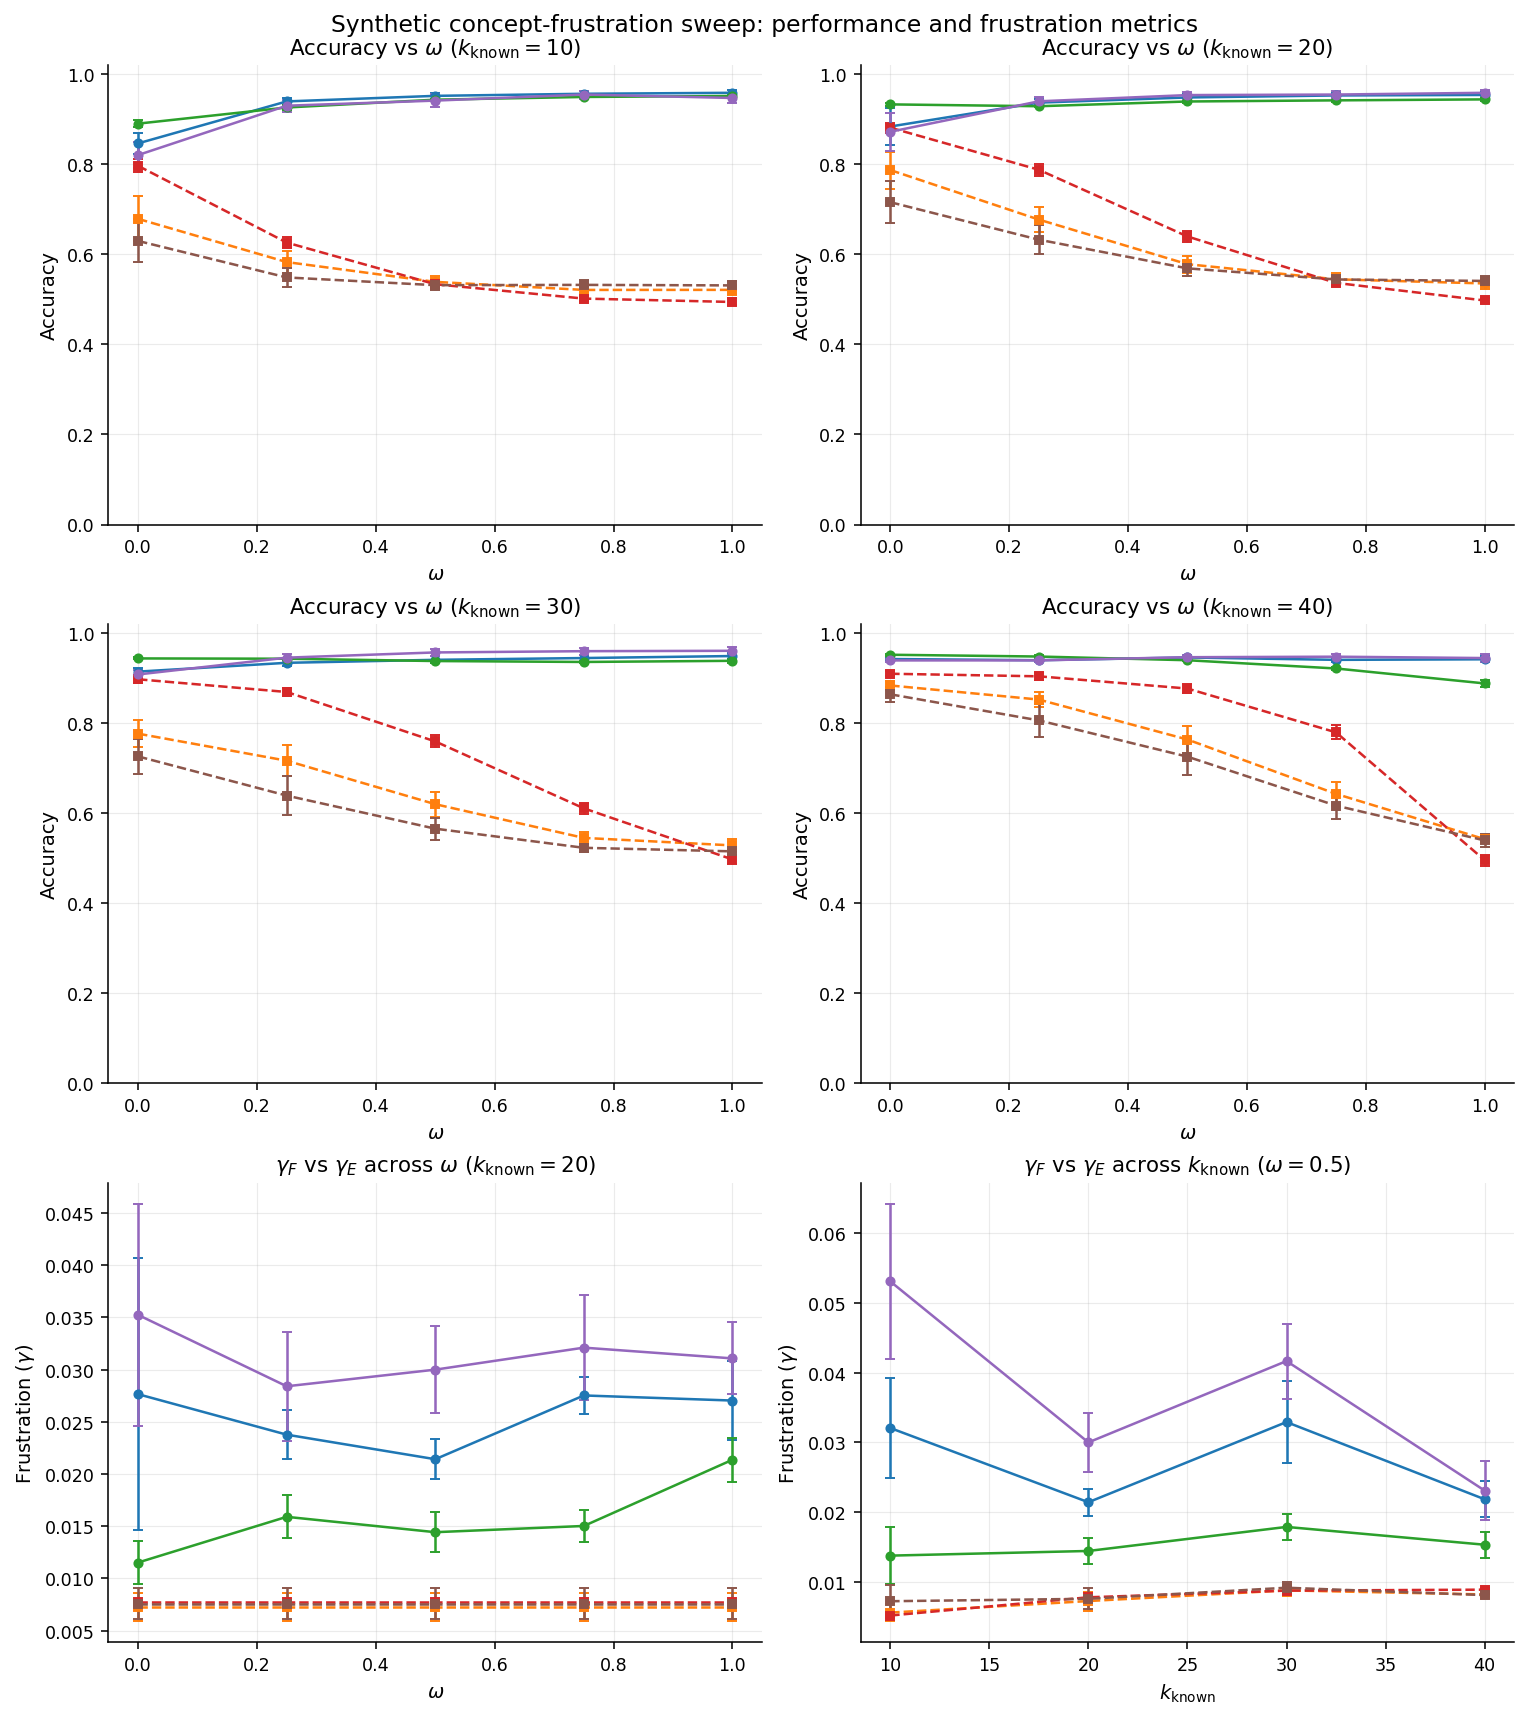

Saved PDF: publication_quality_6panel_hard_CBM_non_sequential.pdf


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- REQUIREMENT: `rows` must already exist (list[dict]) from your run_sweep(...) ----
assert "rows" in globals() and isinstance(rows, list) and len(rows) > 0, "Run the sweep first so `rows` exists."

df = pd.DataFrame(rows).copy()

# Normalise column names (your script uses F_pair_raw_mean/E_pair_raw_mean)
df = df.rename(columns={
    "F_pair_raw_mean": "gamma_F",
    "E_pair_raw_mean": "gamma_E",
})

# Ensure numeric
for c in ["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["seed","k_known","alpha","omega","bb_acc","cbm_acc","gamma_F","gamma_E"]).copy()

# ---------- aggregate across seeds with mean + SEM (error bars) ----------
def sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size <= 1:
        return 0.0
    return float(np.std(x, ddof=1) / np.sqrt(x.size))

agg = (df.groupby(["k_known","alpha","omega"], as_index=False)
         .agg(
             bb_acc_mean=("bb_acc","mean"),
             bb_acc_sem=("bb_acc", sem),
             cbm_acc_mean=("cbm_acc","mean"),
             cbm_acc_sem=("cbm_acc", sem),
             gamma_F_mean=("gamma_F","mean"),
             gamma_F_sem=("gamma_F", sem),
             gamma_E_mean=("gamma_E","mean"),
             gamma_E_sem=("gamma_E", sem),
             n=("seed","nunique"),
         ))

k_list = sorted(agg["k_known"].unique())
alphas = sorted(agg["alpha"].unique())
# Prefer canonical ordering if present
canon = [-1.0, 0.0, 1.0]
alphas = [a for a in canon if any(np.isclose(agg["alpha"], a))] or alphas

# ---------- publication-ish matplotlib defaults (no manual colors) ----------
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def alpha_label(a: float) -> str:
    if np.isclose(a, 1.0):  return r"$\alpha=+1$"
    if np.isclose(a, -1.0): return r"$\alpha=-1$"
    if np.isclose(a, 0.0):  return r"$\alpha=0$"
    return rf"$\alpha={a:.2g}$"

def add_errorbar_line(ax, x, y, yerr, marker, linestyle, label):
    ax.errorbar(
        np.asarray(x), np.asarray(y),
        yerr=np.asarray(yerr),
        marker=marker,
        linestyle=linestyle,
        linewidth=1.3,
        markersize=4.2,
        capsize=2.5,
        label=label,
    )

# ---------- build a SINGLE 6-panel figure (3x2) ----------
# Panels 1-4: Accuracy vs omega for each k_known (6 lines: BB+CBM for α=-1,0,+1)
# Panel 5: gamma_F & gamma_E vs omega for k_known=20 (α-stratified)
# Panel 6: gamma_F & gamma_E vs k_known for omega=0.5 (α-stratified)

# choose up to 4 k_known values for panels 1-4 (if you have >4, we take the first 4 sorted)
k_panels = k_list[:4]
while len(k_panels) < 4 and len(k_list) > 0:  # pad if fewer than 4
    k_panels.append(k_list[-1])

k_target = 20
omega_target = 0.5

fig, axes = plt.subplots(3, 2, figsize=(10.8, 12.0), constrained_layout=True)

# ---- Panels 1-4: accuracy vs omega ----
for idx, k in enumerate(k_panels):
    ax = axes[idx // 2, idx % 2]
    sub = agg[agg["k_known"] == k].sort_values("omega")

    for a in alphas:
        s = sub[np.isclose(sub["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        # BB (solid, circles)
        add_errorbar_line(
            ax,
            s["omega"], s["bb_acc_mean"], s["bb_acc_sem"],
            marker="o", linestyle="-",
            label=f"BB {alpha_label(a)}",
        )
        # CBM (dashed, squares)
        add_errorbar_line(
            ax,
            s["omega"], s["cbm_acc_mean"], s["cbm_acc_sem"],
            marker="s", linestyle="--",
            label=f"CBM {alpha_label(a)}",
        )

    ax.set_title(rf"Accuracy vs $\omega$ ($k_{{\mathrm{{known}}}}={int(k)}$)")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0.0, 1.02)
    ax.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 5: gamma vs omega for k_known=20 ----
ax5 = axes[2, 0]
sub5 = agg[agg["k_known"] == k_target].sort_values("omega")
if len(sub5) == 0:
    ax5.text(0.5, 0.5, f"No data for k_known={k_target}", ha="center", va="center")
    ax5.set_axis_off()
else:
    for a in alphas:
        s = sub5[np.isclose(sub5["alpha"], a)].sort_values("omega")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax5,
            s["omega"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax5.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $\omega$ ($k_{{\mathrm{{known}}}}={k_target}$)")
    ax5.set_xlabel(r"$\omega$")
    ax5.set_ylabel(r"Frustration ($\gamma$)")
    ax5.grid(True, alpha=0.25, linewidth=0.6)

# ---- Panel 6: gamma vs k_known for omega=0.5 ----
ax6 = axes[2, 1]
sub6 = agg[np.isclose(agg["omega"], omega_target)].sort_values("k_known")
if len(sub6) == 0:
    ax6.text(0.5, 0.5, f"No data for omega={omega_target}", ha="center", va="center")
    ax6.set_axis_off()
else:
    for a in alphas:
        s = sub6[np.isclose(sub6["alpha"], a)].sort_values("k_known")
        if len(s) == 0:
            continue

        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_F_mean"], s["gamma_F_sem"],
            marker="o", linestyle="-",
            label=rf"$\gamma_F$ {alpha_label(a)}",
        )
        add_errorbar_line(
            ax6,
            s["k_known"], s["gamma_E_mean"], s["gamma_E_sem"],
            marker="s", linestyle="--",
            label=rf"$\gamma_E$ {alpha_label(a)}",
        )

    ax6.set_title(rf"$\gamma_F$ vs $\gamma_E$ across $k_{{\mathrm{{known}}}}$ ($\omega={omega_target}$)")
    ax6.set_xlabel(r"$k_{\mathrm{known}}$")
    ax6.set_ylabel(r"Frustration ($\gamma$)")
    ax6.grid(True, alpha=0.25, linewidth=0.6)


fig.suptitle("Synthetic concept-frustration sweep: performance and frustration metrics", y=1.01)

plt.show()

# ---- Export as vector PDF (editable text) ----
out_pdf = "publication_quality_6panel_hard_CBM_non_sequential.pdf"
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
print(f"Saved PDF: {out_pdf}")



In [5]:
import pandas as pd

# Convert rows to DataFrame
df = pd.DataFrame(rows).copy()

# Export raw results
df.to_csv("results_updated_matching_B_new_code_acc_metrics_hard_CBM_non_sequential.csv", index=False)
###i think no scale is better
print("Saved raw results to results_raw.csv")


Saved raw results to results_raw.csv
